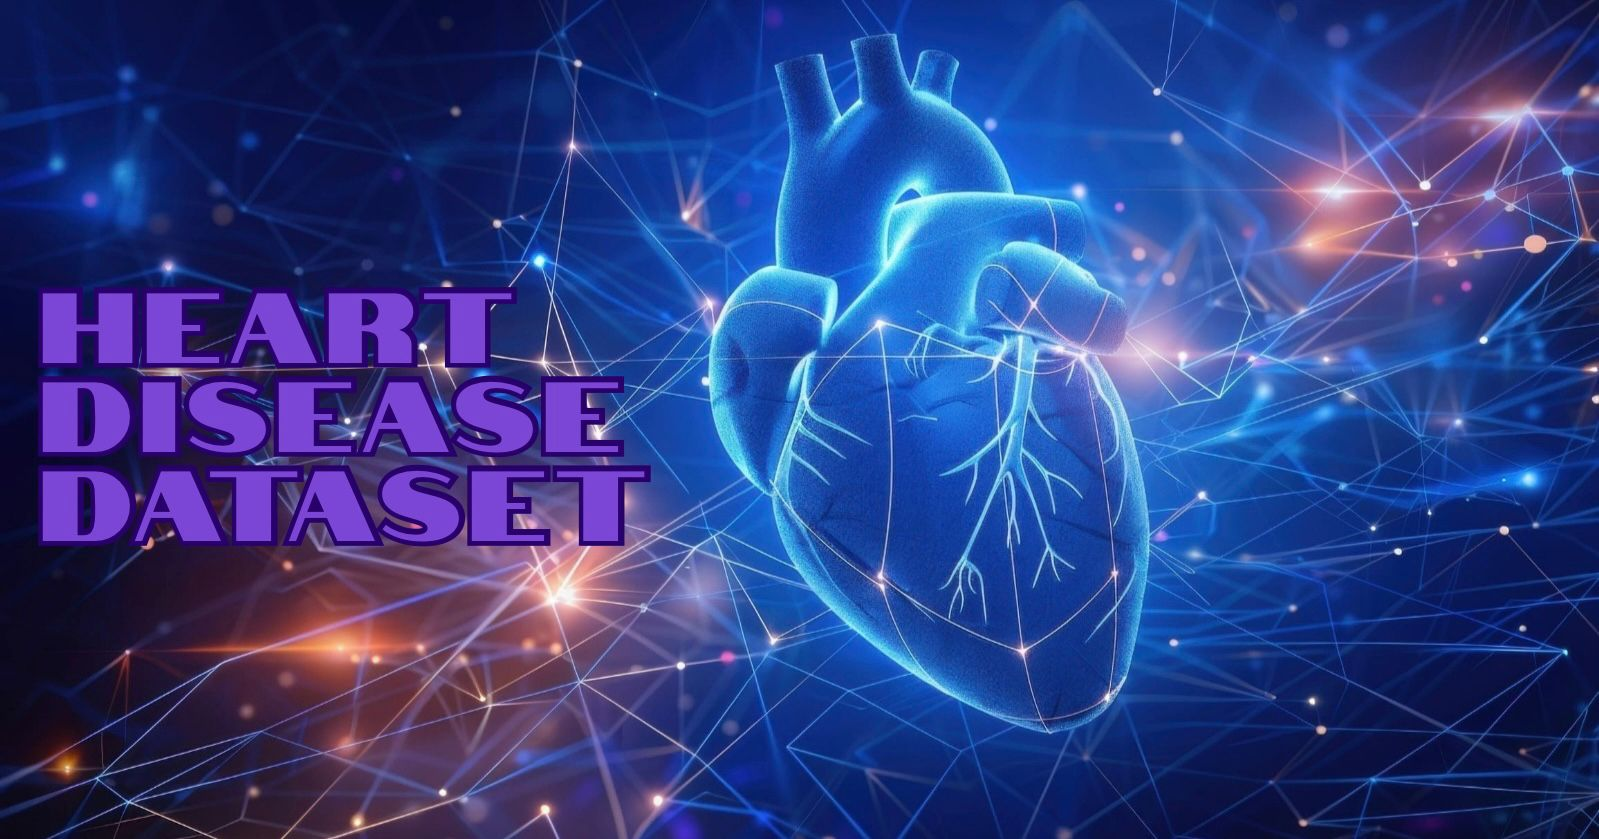

## Work structure:
##### Историческая справка
##### Исследовательский анализ (EDA)
##### Анализ категориальных признаков
##### Анализ числовых признаков
##### Анализ корреляции
##### Анализ аутлаеров
##### Feature engeeniring
##### Base model and feature engeeniring
##### Results evaluation
##### Confusion matrix, classification report

## Problem
#### Бинарная классификация
#### Предсказание наличия болезни сердца по медицинским данным пациента.

## About this dataset

#### История и происхождение
Создан в результате клинических исследований, проведённых в четырёх медицинских центрах США:

Cleveland Clinic Foundation (Кливленд, штат Огайо)

Hungarian Institute of Cardiology (Будапешт)

VA Medical Center (Long Beach, Калифорния)

University Hospital, Zurich, Switzerland

Инициатива: Исходно датасет был собран для оценки методов неинвазивной диагностики сердечно-сосудистых заболеваний, особенно ишемической болезни сердца (ангина, инфаркт).

 Цель: Облегчить разработку алгоритмов, способных предсказать вероятность наличия болезни сердца по ряду медицинских показателей, таких как артериальное давление, уровень холестерина, наличие боли в груди и др.

Опубликован: В репозитории UCI Machine Learning Repository — одном из старейших и наиболее уважаемых источников для обучающих данных в машинном обучении.

Оригинальное описание в UCI:
Название: Heart Disease Data Set

Атрибутов: 76 в полном датасете (но для анализа чаще всего используют только 14),как в нашем случае.

Основной "gold standard" датасет — Cleveland, поскольку он самый полный и часто используется в исследованиях (именно 303 наблюдения).

## Import libraries and EDA analysis

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
# feature engeeniring
from feature_engine.imputation import MeanMedianImputer, CategoricalImputer
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OneHotEncoder
from feature_engine.wrappers import SklearnTransformerWrapper
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
# feature Selection
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score


import warnings
warnings.filterwarnings('ignore')

In [121]:
df = pd.read_csv('../heartDisease_dataset_TP.csv')

In [122]:
df.shape

(303, 14)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    float64
 1   sex       300 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  299 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       299 non-null    float64
 6   restecg   300 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     298 non-null    float64
 9   oldpeak   300 non-null    float64
 10  slope     297 non-null    float64
 11  ca        298 non-null    float64
 12  thal      300 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [124]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,294.000000,300.000000,297.000000,299.000000,297.000000,299.000000,300.000000,291.000000,298.000000,300.000000,297.000000,298.000000,300.000000,303.000000
mean,54.394558,0.683333,0.966330,131.505017,246.084175,0.147157,0.526667,149.505155,0.328859,1.046000,1.404040,0.734899,2.310000,0.544554
std,9.106168,0.465953,1.035947,17.502516,52.016723,0.354856,0.526192,22.824574,0.470589,1.163729,0.613792,1.028315,0.612495,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.250000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,195.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [125]:
df.isnull().sum()

age          9
sex          3
cp           6
trestbps     4
chol         6
fbs          4
restecg      3
thalach     12
exang        5
oldpeak      3
slope        6
ca           5
thal         3
target       0
dtype: int64

In [126]:
disease = df[df['target']==1]
healthy = df[df['target']==0]

In [127]:
print('Total = ', len(df))
print('Number of disease patient = ', len(disease))
print('Percentage of disease = ', 1.* len(disease) / len(df)*100.0, '%')
print('Healty patient = ', len(healthy))
print('Percentage of healthy patient = ', 1.*len(healthy) / len(df) * 100.0, '%')

Total =  303
Number of disease patient =  165
Percentage of disease =  54.45544554455446 %
Healty patient =  138
Percentage of healthy patient =  45.54455445544555 %


In [128]:
# Карта доменных кодов (числовые, но это категории): обрабатываем как категориальные
cat_cols = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('target')

# Категориальные коды как категории, всё остальное числовое
discrete_cols = [col for col in num_cols if df[col].nunique()]
continuous_cols = [col for col in num_cols if col not in discrete_cols]

cat_cols, num_cols

(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'],
 ['age',
  'sex',
  'cp',
  'trestbps',
  'chol',
  'fbs',
  'restecg',
  'thalach',
  'exang',
  'oldpeak',
  'slope',
  'ca',
  'thal'])

## Анализ распределений 

In [129]:
# Словарь для читаемых подписей
mappings = {
    "sex": {0: "Female", 1: "Male"},
    "cp": {0: "Asymptomatic", 1: "Atypical Angina", 2: "Non-anginal Pain", 3: "Typical Angina"},
    "fbs": {0: "<120 mg/dl", 1: ">120 mg/dl"},
    "restecg":{0: "Normal", 1: "ST-T Abnormality", 2: "Left Ventricular Hypertrophy"},
    "exang": {0: "No", 1: "Yes"},
    "slope": {0: "Upsloping", 1: "Flat", 2: "Downsloping"},
    "ca": {0: "0 Vessels", 1: "1 Vessel", 2: "2 Vessels", 3: "3 Vessels", 4: "4 Vessels"},
    "thal": {1: "Fixed Defect", 2: "Normal", 3: "Reversible Defect"},
    "target": {0: "No Heart Disease", 1: "Heart Disease"},
}

In [130]:
# Применим маппинги для отображения
df_mapped = df.copy()
for col, mapping in mappings.items():
    if col in df_mapped.columns:
        df_mapped[col] = df_mapped[col].map(mapping)

# Вспомогательная функция для подписей процентов 
def annotate_percent(ax, total):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{100*h/total:.1f}%", 
                        (p.get_x() + p.get_width()/2., h),
                        ha="center", va="bottom", fontsize=9, color="black")

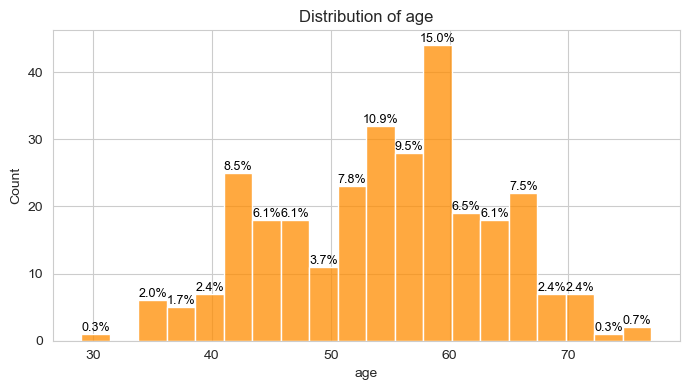

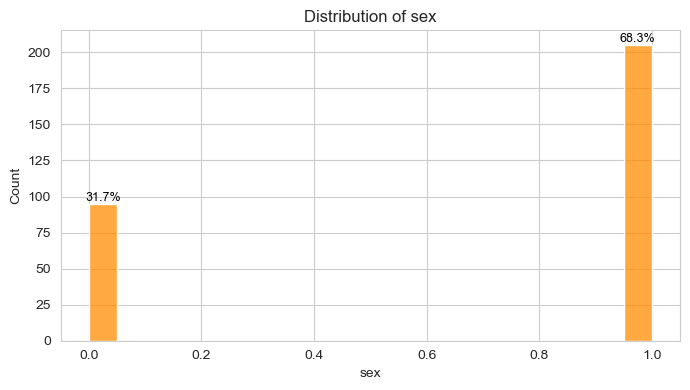

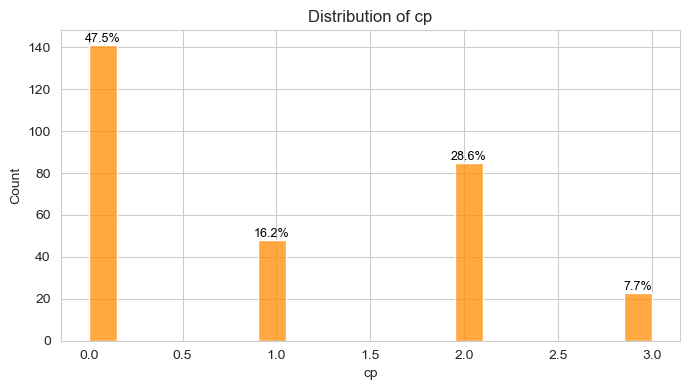

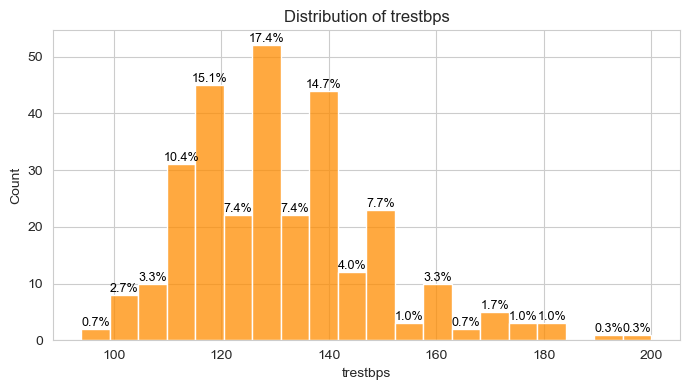

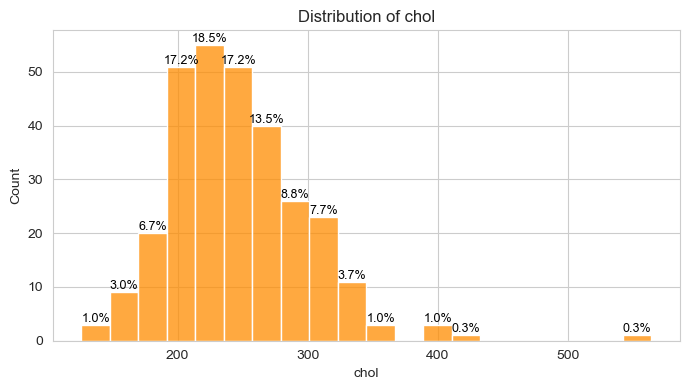

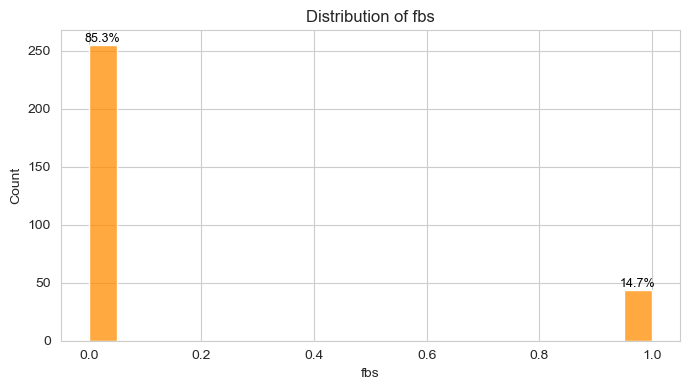

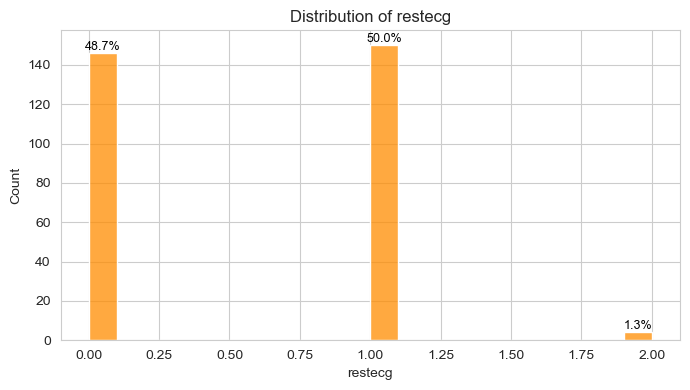

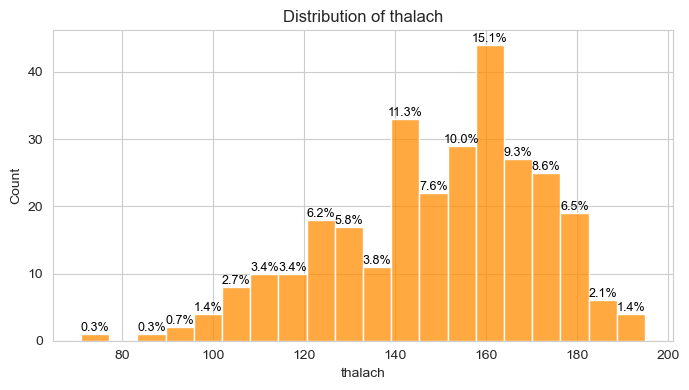

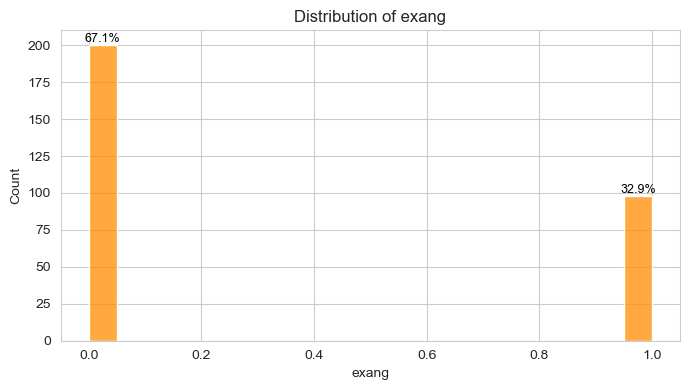

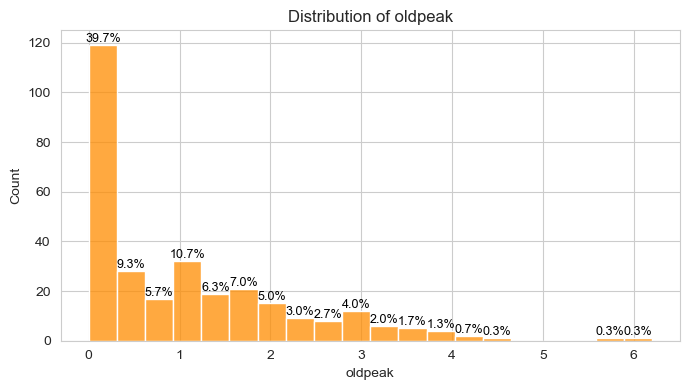

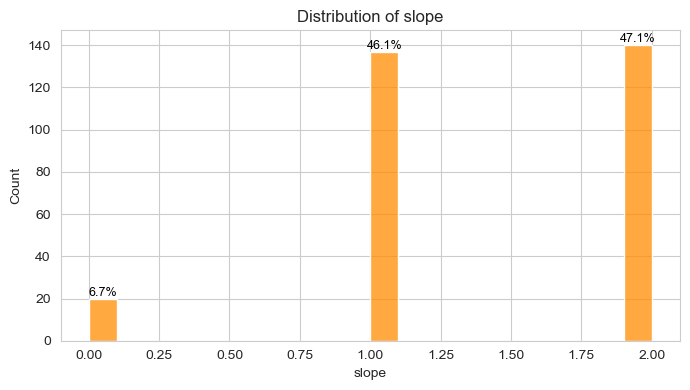

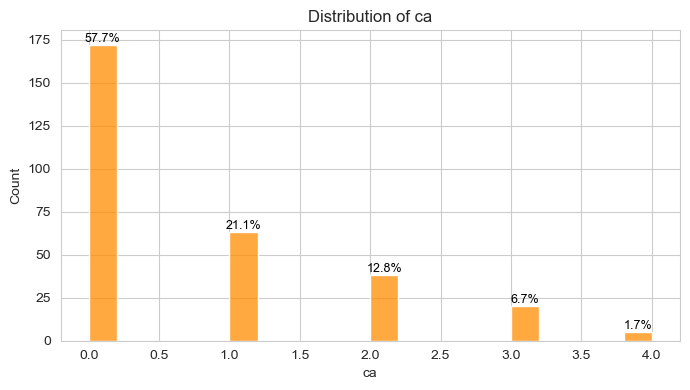

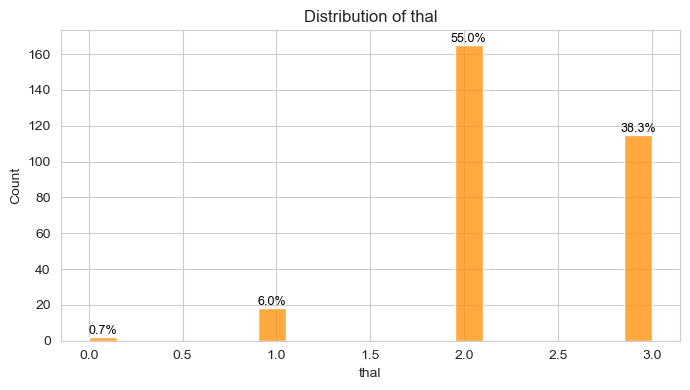

In [131]:
# ЧИСЛОВЫЕ гистограммы 
sns.set_style('whitegrid')
for col in num_cols:
    if col not in df.columns:
        continue
    plt.figure(figsize=(7, 4))
    ax = sns.histplot(df[col].dropna(), bins=20, color="darkorange", edgecolor=None)
    total = len(df[col].dropna())
    annotate_percent(ax, total)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

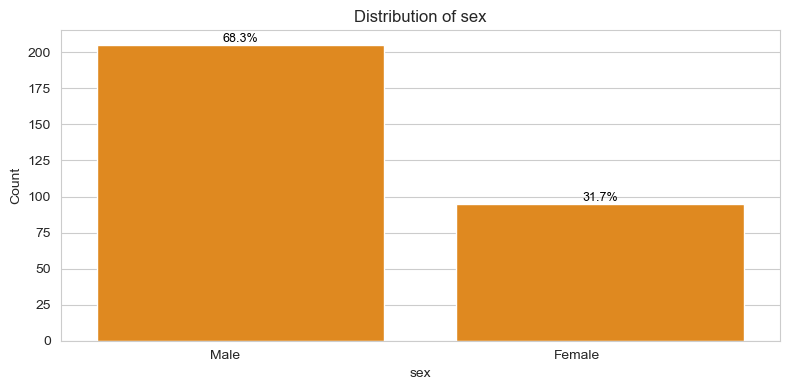

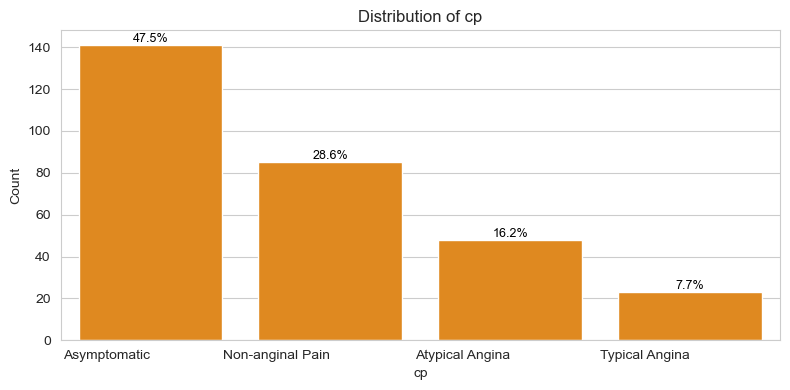

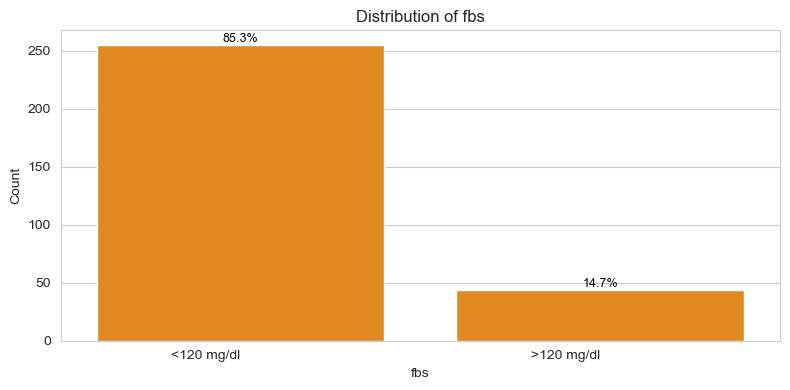

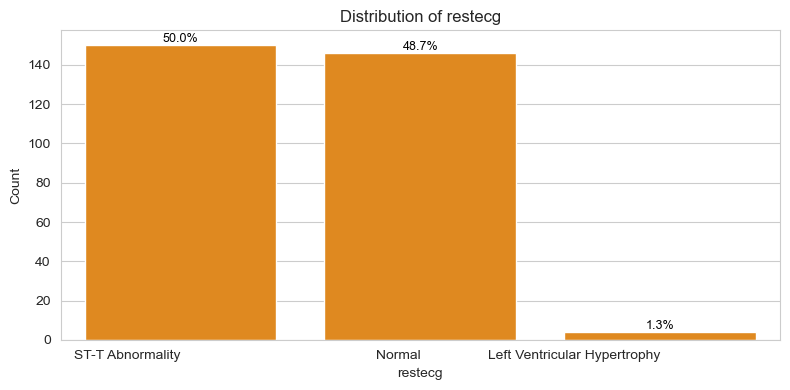

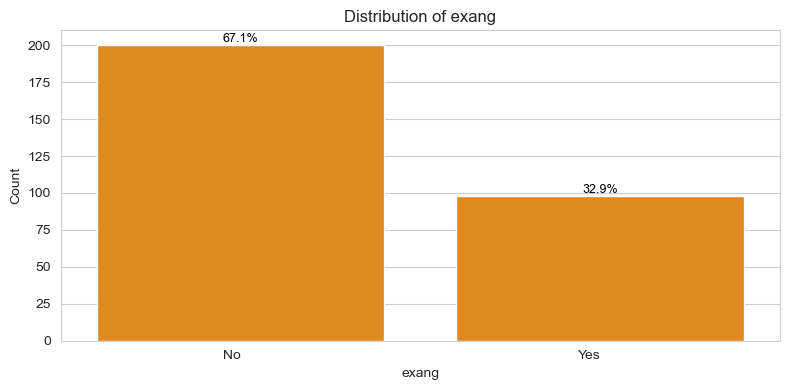

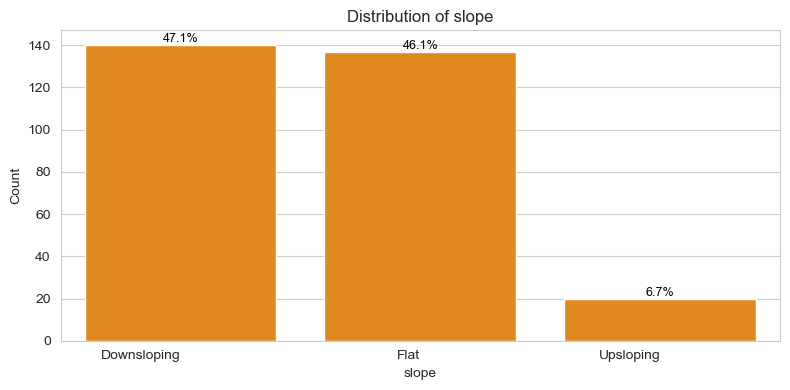

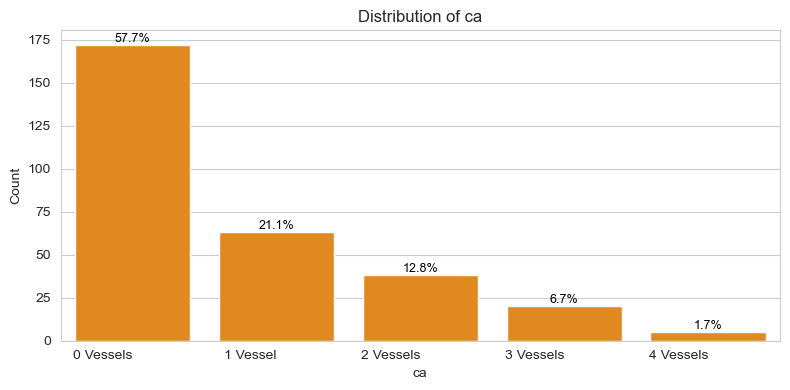

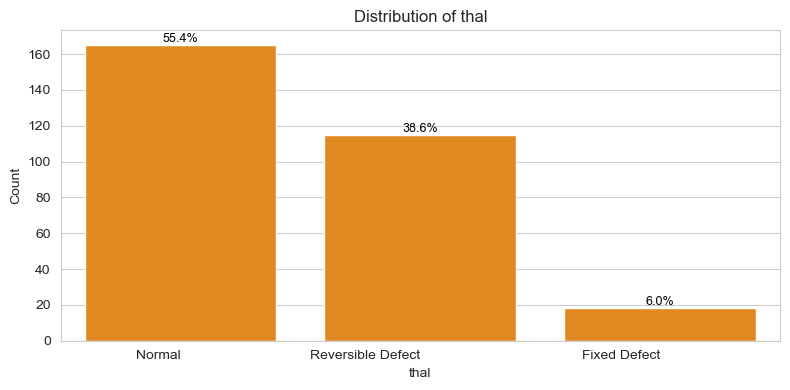

In [132]:
# КАТЕГОРИАЛЬНЫЕ:
sns.set_style("whitegrid")
for col in cat_cols:
    if col not in df_mapped.columns:
        continue
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(
        x=col, 
        data=df_mapped, 
        color="darkorange", 
        order=df_mapped[col].value_counts().index
    )
    total = df_mapped[col].notna().sum()
    annotate_percent(ax, total)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.xticks(rotation=0, ha="right")
    plt.tight_layout()
    plt.show()

## Влияние на таргет

In [133]:
df_mapped = df.copy()
for col, mapping in mappings.items():
    if col in df_mapped.columns:
        df_mapped[col] = df_mapped[col].map(mapping)

def plot_feature_distribution(df, column, target="target"):
    plt.figure(figsize=(8,4))

    if pd.api.types.is_numeric_dtype(df[column]):
        # Числовые признаки (гистограмма по таргету)
        sns.histplot(data=df, x=column, hue=target, kde=True, multiple="stack", palette='plasma')
        plt.title(f"Distribution of {column} by Target")
        plt.ylabel("Count")
    
    else:
        # Категориальные признаки (countplot)
        ax = sns.countplot(data=df, x=column, hue=target,palette='plasma')
        total = len(df)
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                percentage = f"{100*h/total:.1f}%"
                ax.annotate(percentage,
                            (p.get_x() + p.get_width()/2., h),
                            ha="center", va="bottom", fontsize=9)
        plt.title(f"Distribution of {column} by Target")
        plt.xticks(rotation=0, ha="right")
        plt.ylabel("Count")
    
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

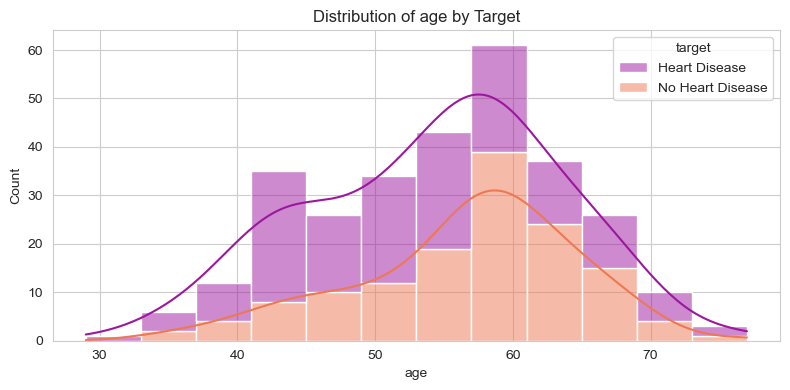

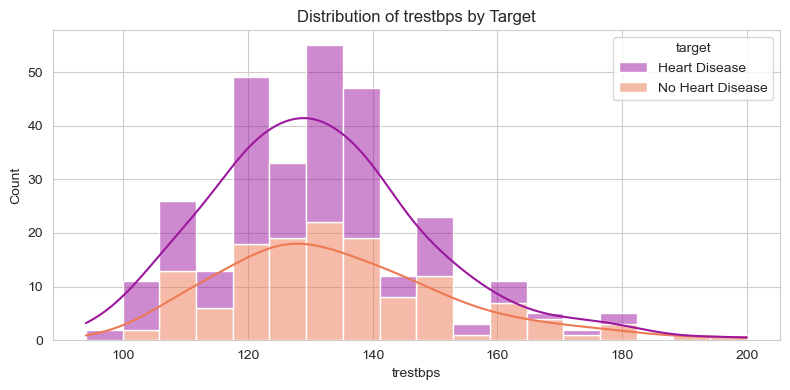

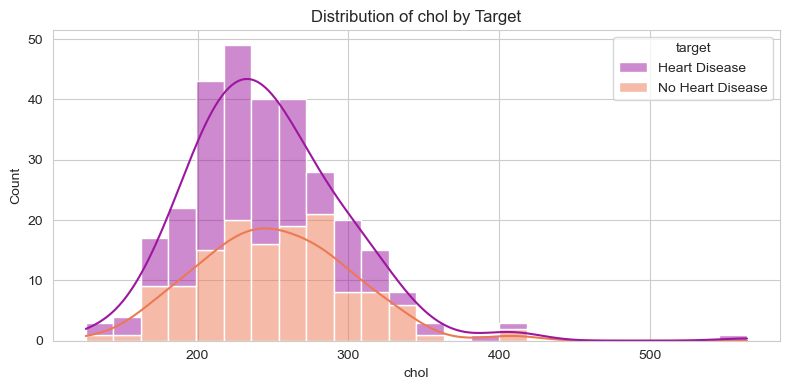

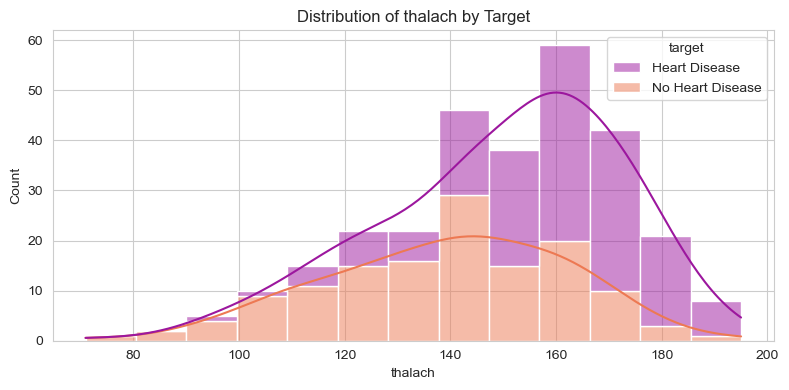

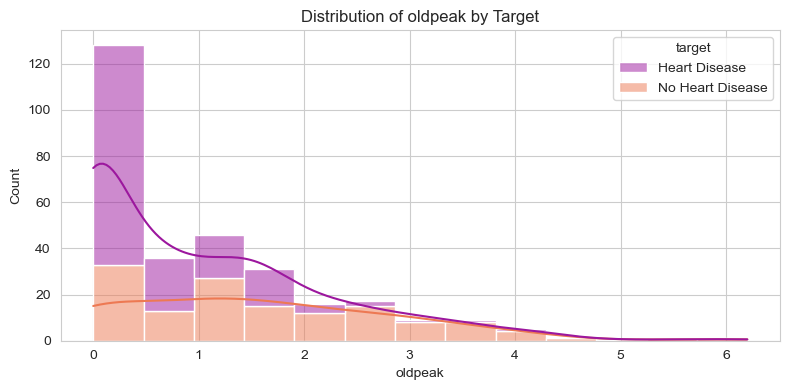

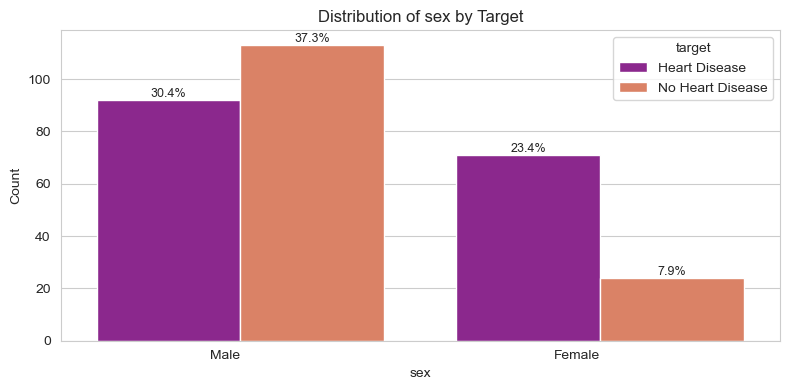

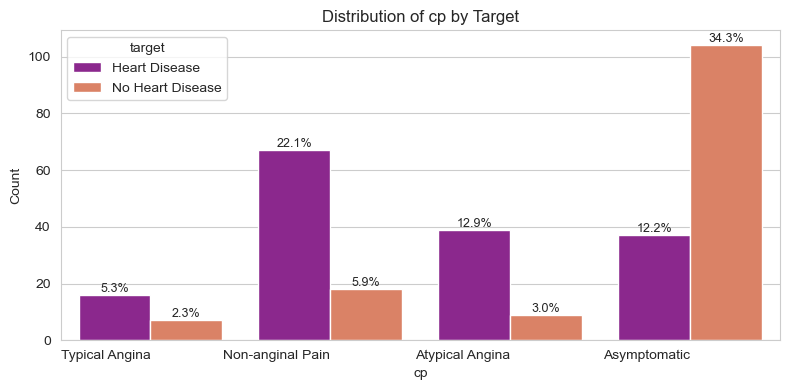

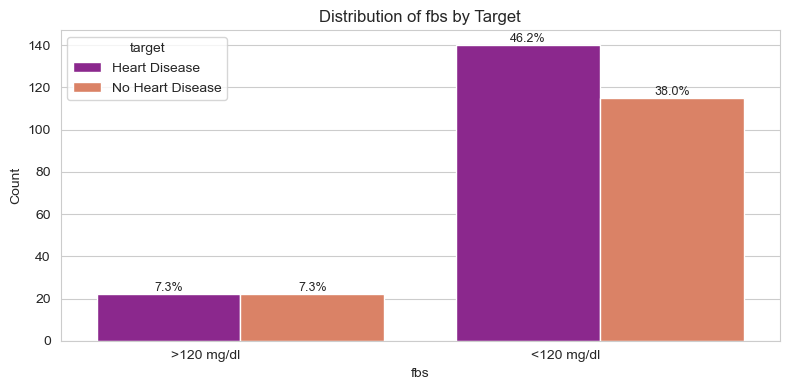

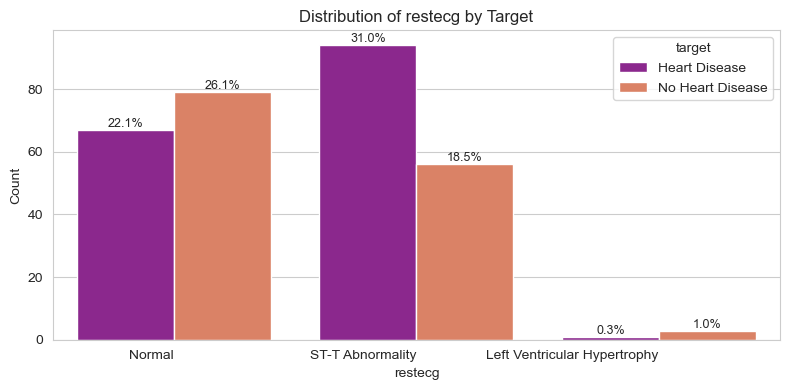

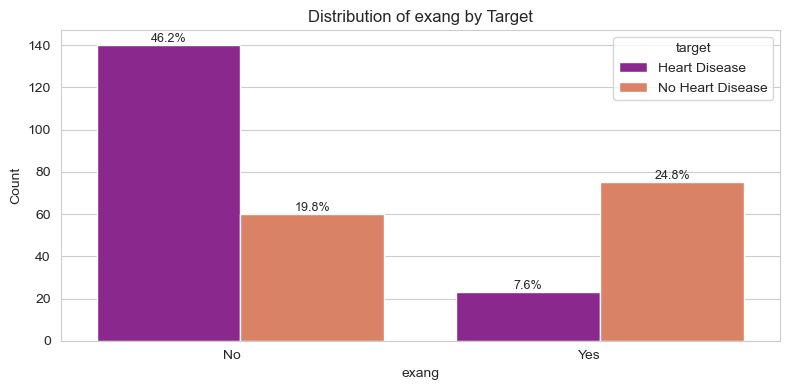

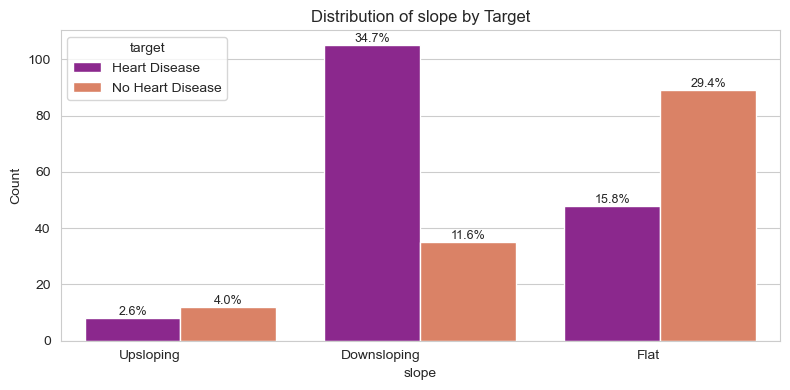

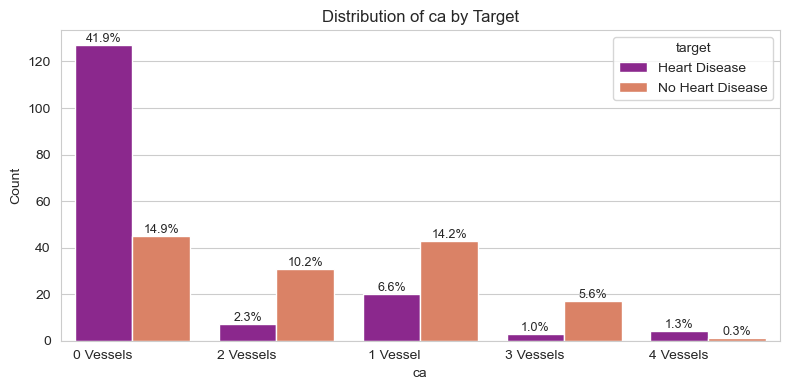

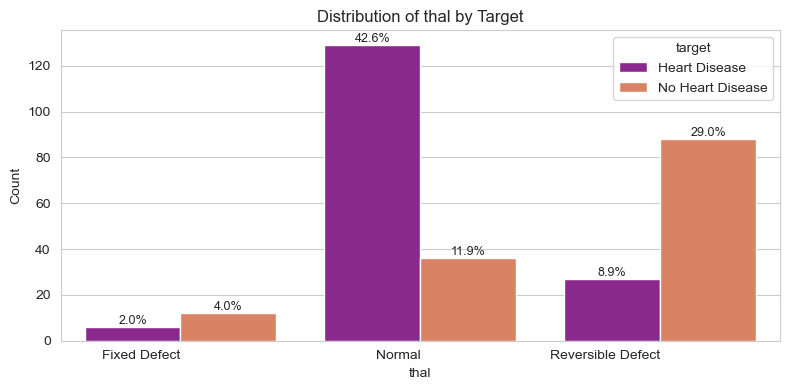

In [134]:
num_cols_all = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols_all = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for col in num_cols_all + cat_cols_all:
    plot_feature_distribution(df_mapped, col, target="target")

## ВЫВОДЫ

#### 1.age-возраст
У пациентов с болезнью (target = 1) возрастное распределение смещено в сторону среднего возраста (40–60 лет).
У здоровых (target = 0) больше людей старше 60.
Вывод: болезнь чаще встречается в среднем возрасте, но у пожилых доля без болезни выше — возможно, это связано с выборкой или тем, что в исследовании выжившие пожилые люди уже более «отобранные» по здоровью.

#### 2. sex-пол (1 = мужчина, 0 = женщина)
Мужчины значительно преобладают в обеих группах.
Доля женщин выше среди больных (оранжевые) относительно их общей численности.
Вывод: мужчины чаще встречаются в выборке, но среди женщин пропорция с болезнью выше, что может указывать на меньшую защищённость женского пола в этой выборке или на особенности диагностики.

#### 3. cp-тип боли в груди (0–3)
cp = 0 (типичная стенокардия) — чаще у здоровых.
cp = 1–3 — ярко выражено у больных, особенно cp = 2.
Вывод: нетипичные боли в груди (cp = 2) ассоциированы с болезнью.

#### 4. trestbps-давление в покое
Распределения почти перекрываются.
Есть небольшой сдвиг: у больных чуть чаще давление 120–140.
Вывод: давление не даёт явного разделения по болезни, но есть лёгкая тенденция.

#### 5. chol-холестерин
Диапазоны значений схожи.
Есть лёгкая тенденция: у больных чуть выше концентрация 200–250.
Вывод: холестерин слабо дифференцирует группы.

#### 6. fbs-сахар натощак > 120 мг/дл (1 = да)
Почти все значения 0.
Вывод: признак малополезен для разделения (низкая вариативность).

#### 7. restecg-ЭКГ в покое
Значения 0 и 1 встречаются в обеих группах, но у больных чуть чаще restecg = 1.
Вывод: слабая, но заметная связь.

#### 8. thalach-максимальный пульс
У больных пульс выше (140–170), у здоровых — чаще ниже 130.
Вывод: высокая ЧСС при нагрузке чаще у больных.

#### 9. exang-стенокардия при нагрузке (1 = да)
У здоровых чаще exang = 1.
Вывод: отсутствие стенокардии при нагрузке связано с болезнью (парадокс, возможно, из-за типа теста).

#### 10. oldpeak-депрессия сегмента ST
У здоровых чаще значения > 2.
У больных в основном низкие значения (< 1).
Вывод: неожиданно, большие oldpeak встречаются у здоровых (возможно, артефакт данных или особенности теста).

#### 11. slope-наклон сегмента ST
slope = 2 (восходящий) чаще у больных.
Вывод: форма кривой ST может быть индикатором болезни.

#### 12. ca -количество крупных сосудов
У больных чаще ca = 0, у здоровых — больше распределение по 1–3.
Вывод: отсутствие видимых сосудистых поражений (ca = 0) связано с болезнью в этой выборке — возможно, связано с методикой измерения.

#### 13. thal-талассемия (0–3)
thal = 2 и thal = 3 чаще у больных.
Вывод: определённые типы талассемии ассоциированы с болезнью.

#### 14. target-целевая переменная
Два класса сбалансированы почти поровну.
Вывод: выборка хорошо сбалансирована для обучения модели.

## Корреляция

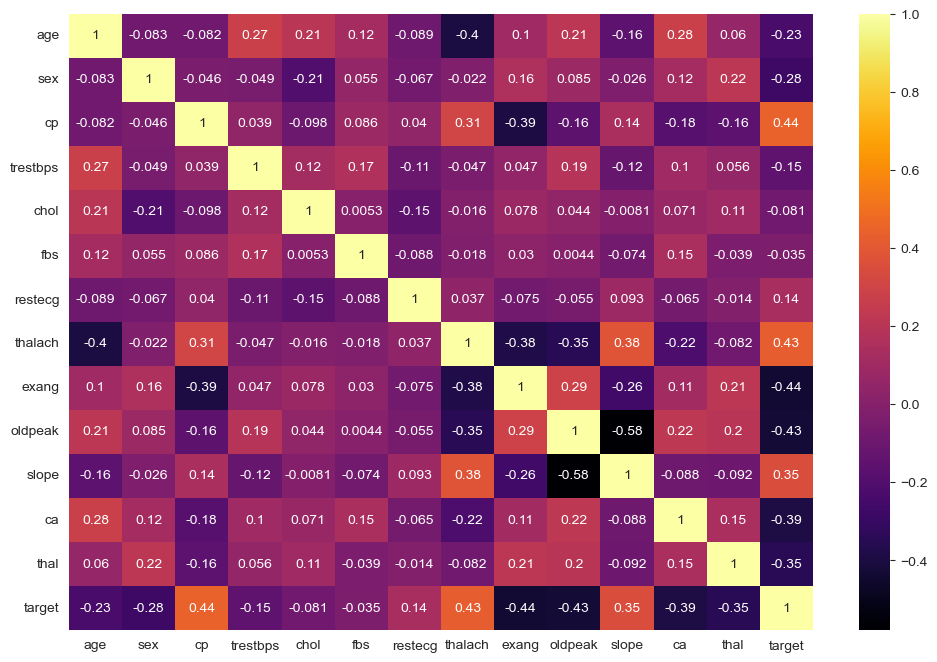

In [135]:
corrMatrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8)) 
sns.heatmap(corrMatrix, cmap="inferno", annot=True)
plt.show()

### Основные наблюдения:
##### CP (тип боли в груди) и THALACH (максимальная ЧСС) имеют наибольшую положительную корреляцию с target.

##### EXANG (стенокардия при нагрузке), OLDPEAK, CA, THAL имеют наибольшую отрицательную корреляцию с target.

##### AGE и холестерин (CHOL) слабо связаны с целевой переменной.

##### Есть заметные сильные взаимосвязи между признаками: OLDPEAK и SLOPE (−0.58).

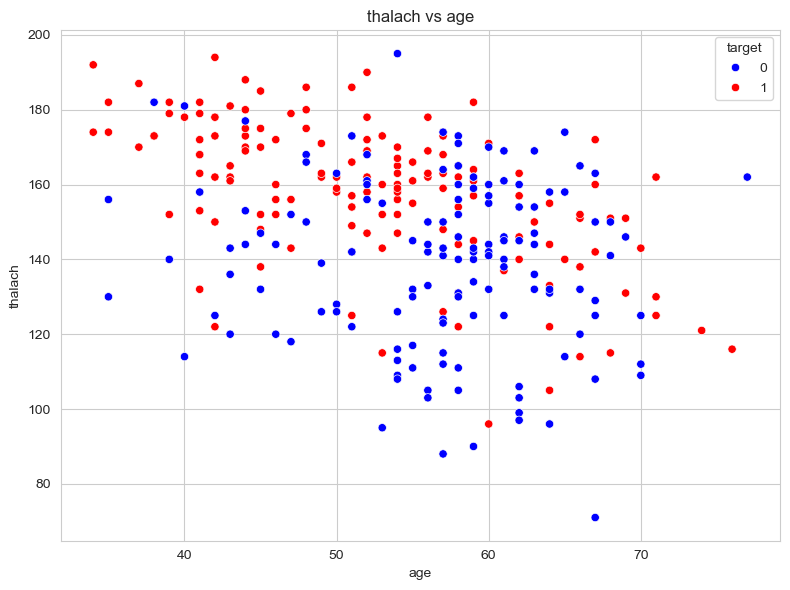

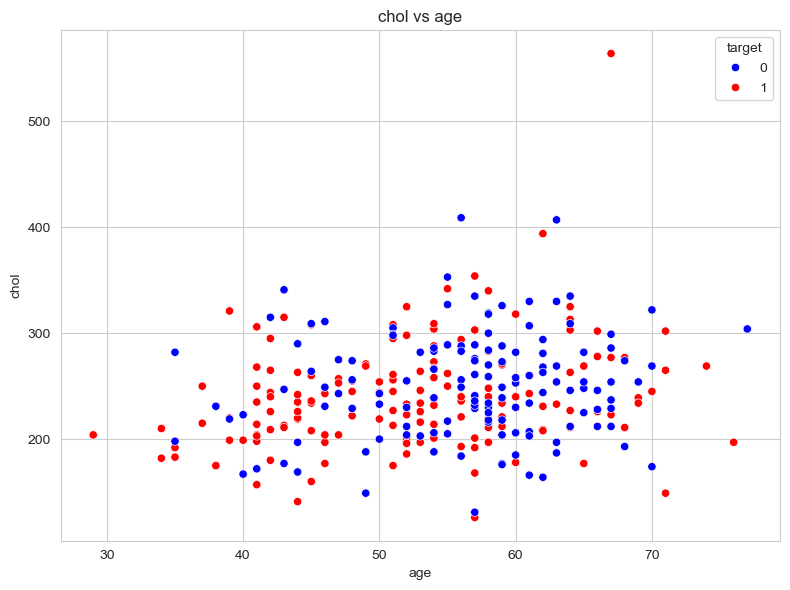

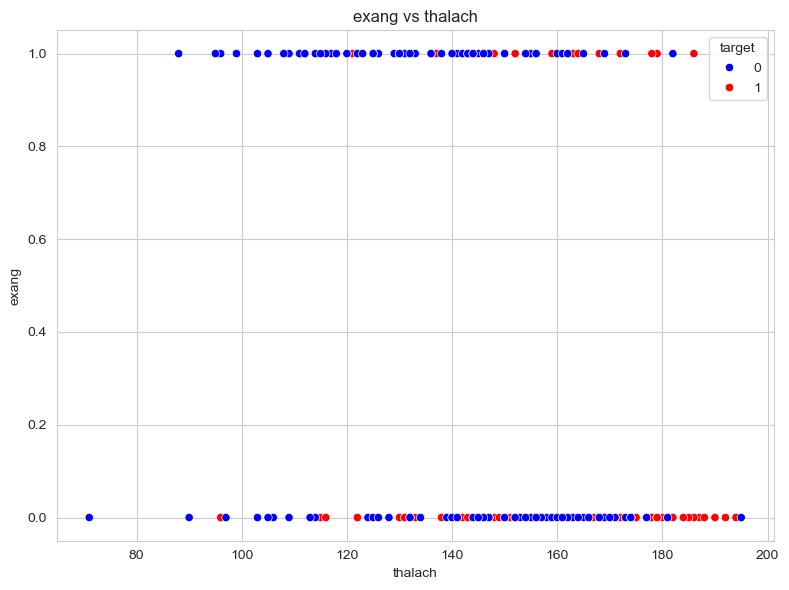

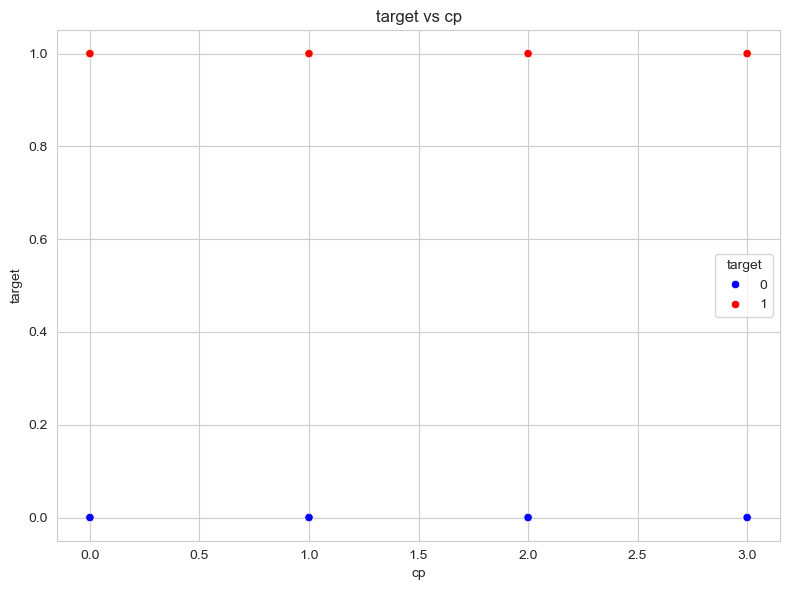

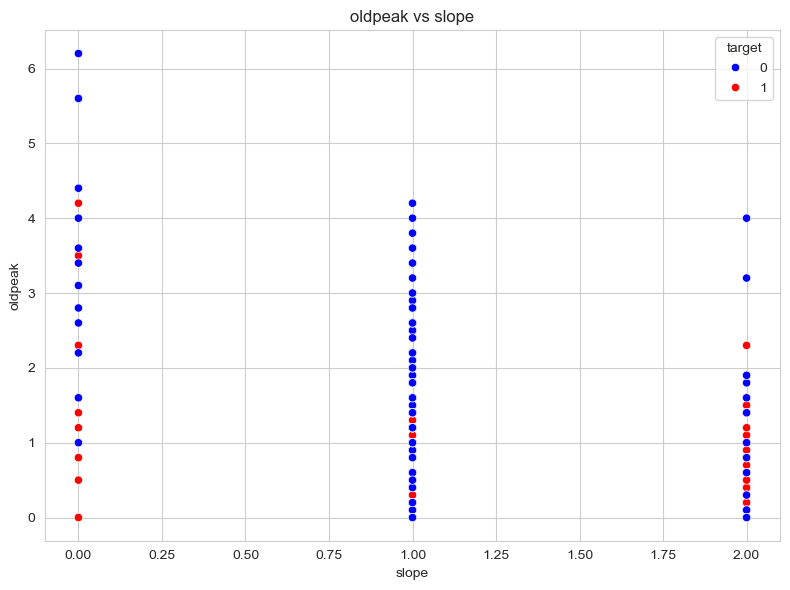

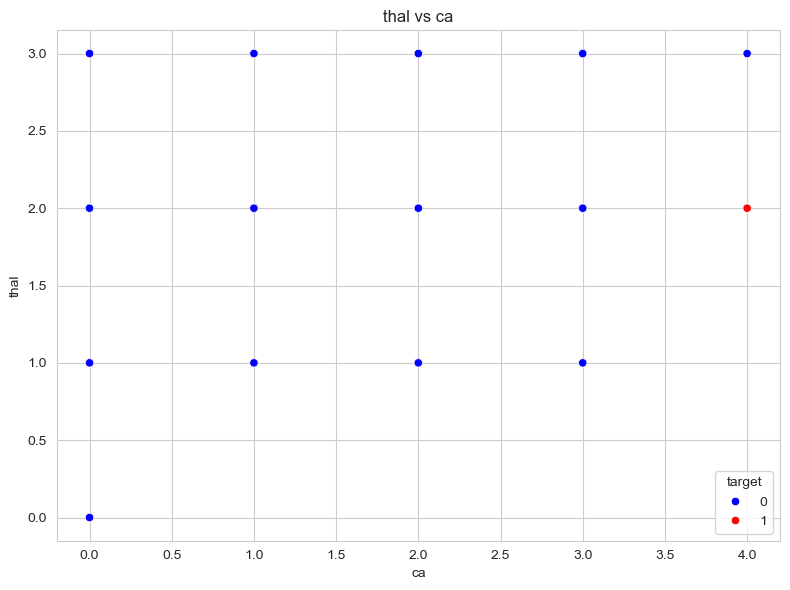

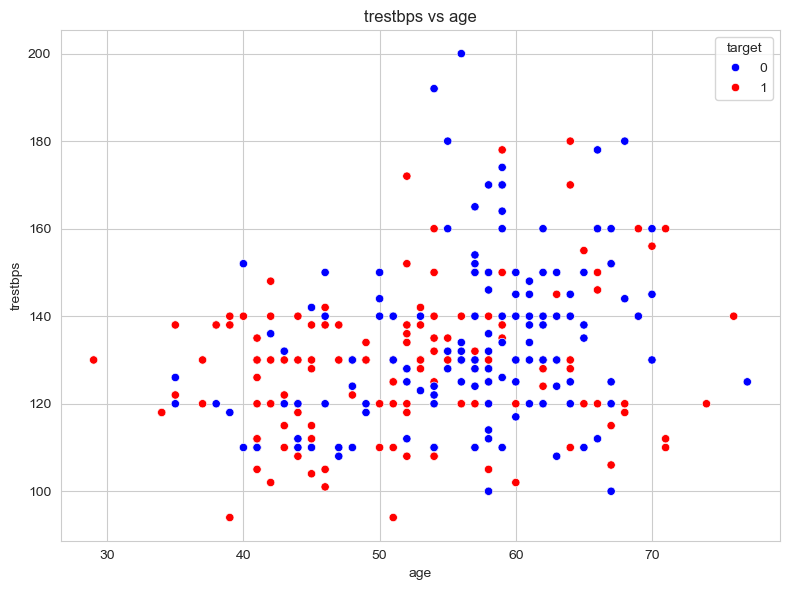

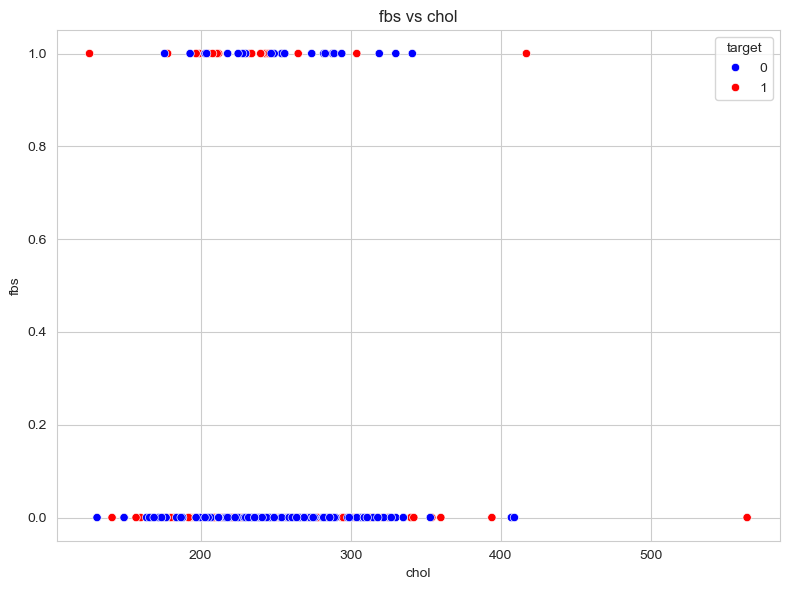

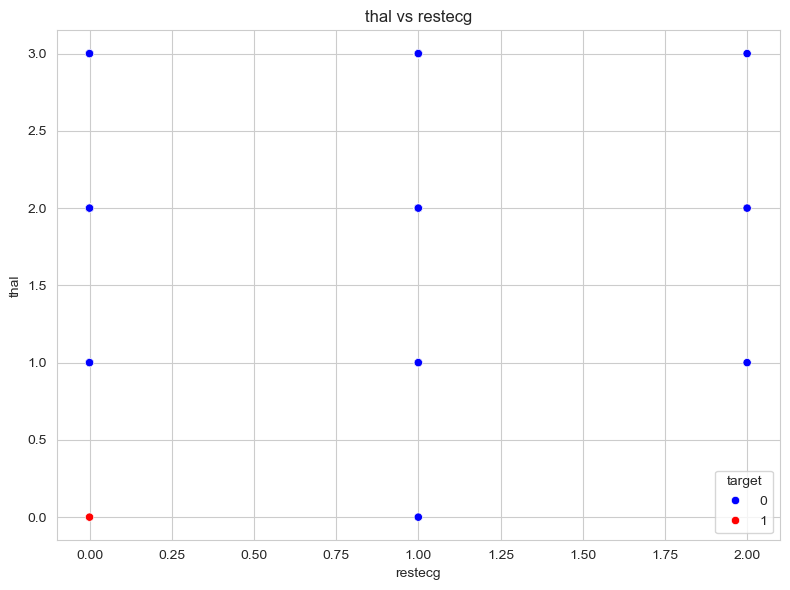

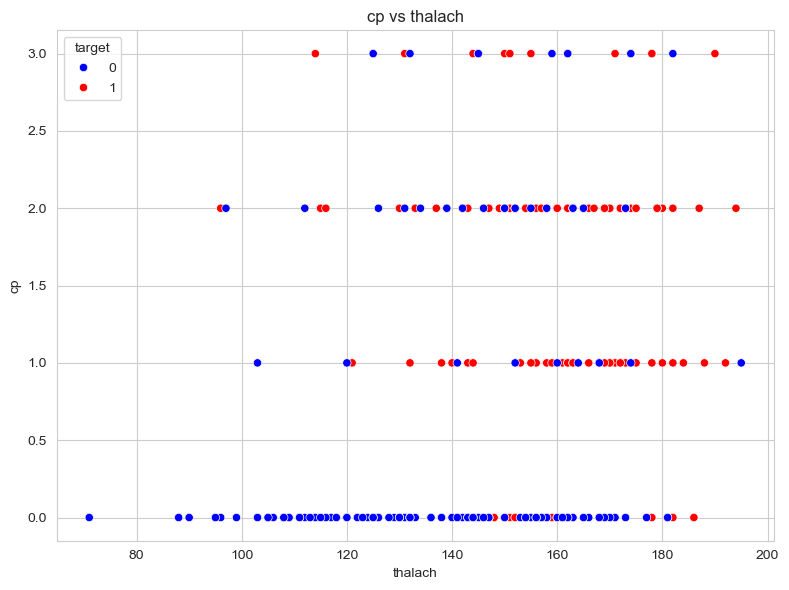

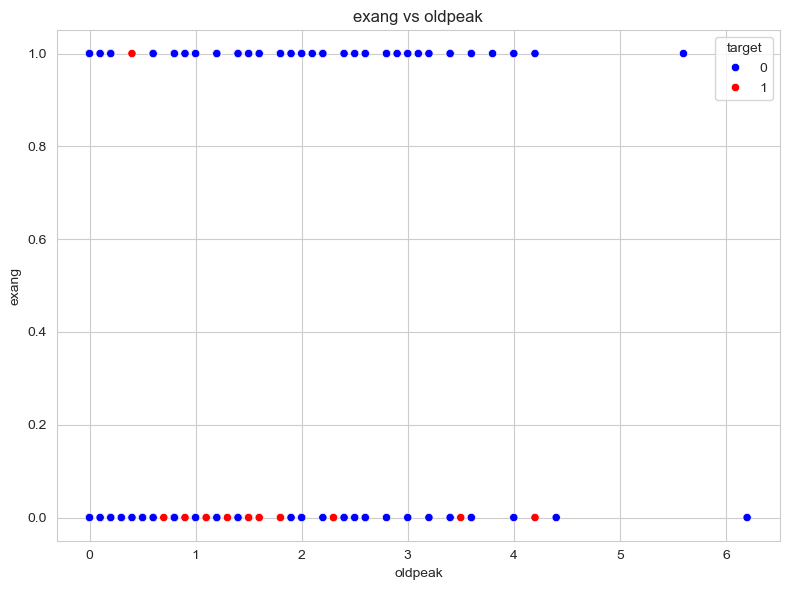

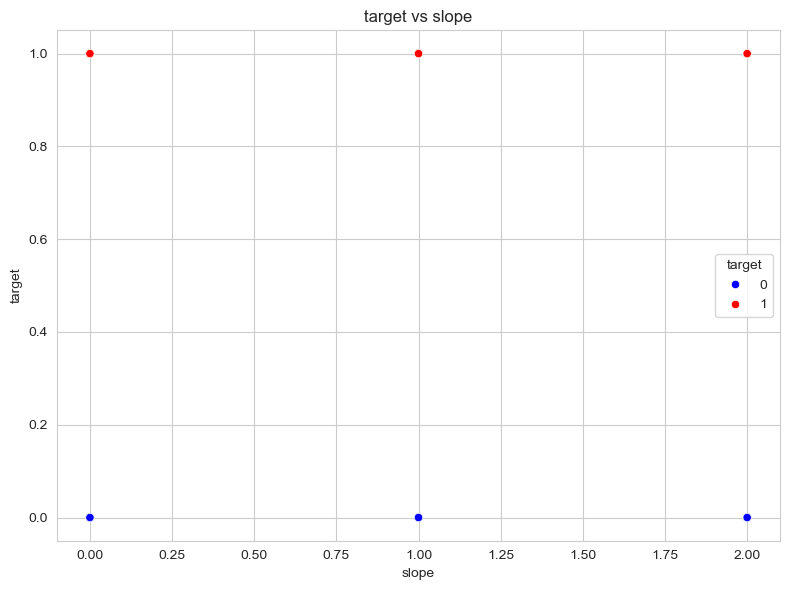

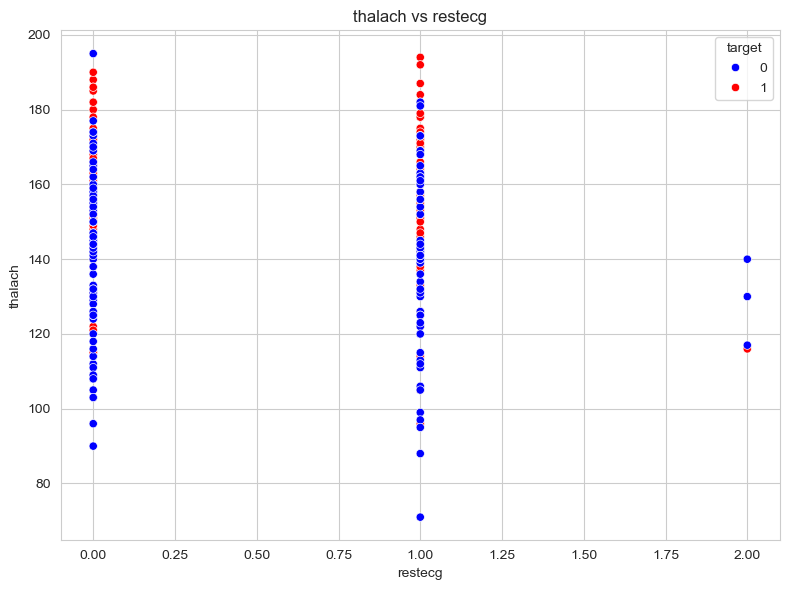

In [136]:
plt.rcParams['figure.figsize'] = (8, 6)

# Список пар признаков для визуализации
pairs_to_plot = [
    ('age', 'thalach'),
    ('age', 'chol'),
    ('thalach', 'exang'),
    ('cp', 'target'),
    ('slope', 'oldpeak'),
    ('ca', 'thal'),
    ('age', 'trestbps'),
    ('chol', 'fbs'),
    ('restecg', 'thal'),
    ('thalach', 'cp'),
    ('oldpeak', 'exang'),
    ('slope', 'target'),
    ('restecg', 'thalach')
]

for x, y in pairs_to_plot:
    sns.scatterplot(data=df, x=x, y=y, hue='target', palette={0: 'blue', 1: 'red'} )
    plt.title(f'{y} vs {x}')
    plt.tight_layout()
    plt.show()

## Scatter plots's conclusion
##### thalach vs age:
Наблюдается уменьшение максимальной ЧСС с возрастом.
Пациенты с болезнью (красные) чаще имеют более высокий пульс при меньшем возрасте.
##### chol vs age:
Холестерин растёт с возрастом, но разброс большой.
Нльзя точно отделить здоровых и больных только по холестерину.
##### exang vs thalach:
При exang = 1 (нагрузка вызвала боль) обычно пульс (thalach) ниже.
У больных (target=1) наоборот чаще высокая thalach и exang=0.
##### cp (тип боли) vs target:
Пациенты с cp=1 или cp=2 чаще имеют болезнь.
Тип боли это информативный признак.
##### slope vs oldpeak:
Сильная обратная связь (−0.58).
Пациенты с болезнью чаще имеют низкий slope и высокий oldpeak.
##### ca vs thal:
При увеличении количества пораженных сосудов (ca), часто меняется и thal.
Эти признаки логично сгруппированы.
##### trestbps vs age:
С возрастом наблюдается тенденция к более высокому артериальному давлению.
Однако различие по target не ярко выражено.
##### chol vs fbs:
повышенный сахар (fbs = 1) чаще встречается при высоком уровне холестерина.
Но чёткая граница между больными и здоровыми отсутствует.
##### thal vs restecg:
Некоторые комбинации значений встречаются чаще у больных (target = 1).
Возможны зависимости между ЭКГ и перфузией миокарда.
##### thalach vs cp:
Больные пациенты (target = 1) имеют более высокую частоту пульса при определённых типах боли.
Подтверждает взаимосвязь cp и thalach.
##### oldpeak vs exang:
При наличии физической нагрузки (exang = 1) уровень ST-депрессии (oldpeak) чаще выше.
Для (target=1) чаще встречаются большие значения oldpeak при exang=0.
##### slope vs target:
Пациенты с определённым типом наклона сегмента ST (например, slope = 2) чаще болеют.
slope=1 чаще у здоровых.

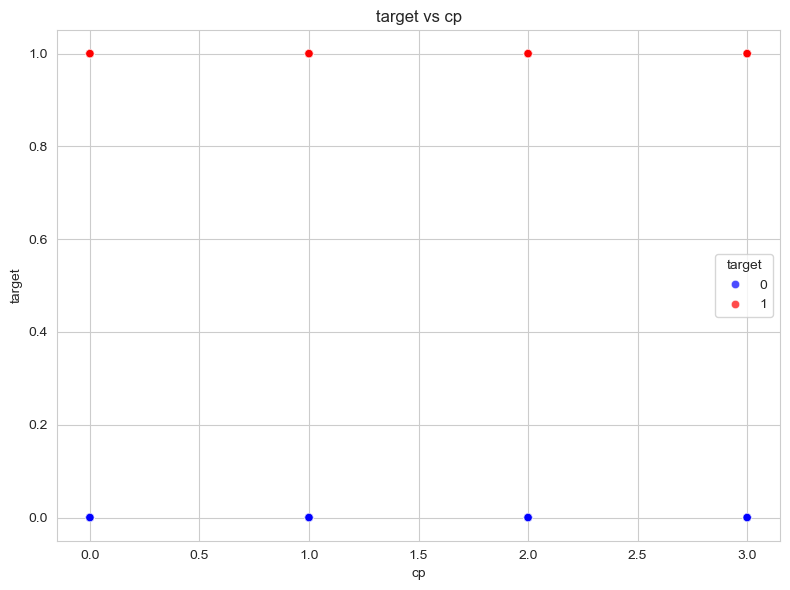

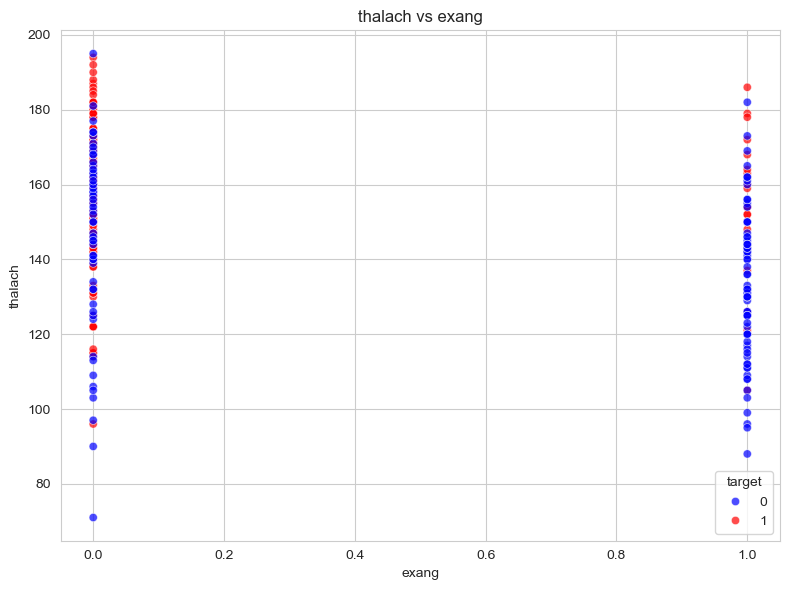

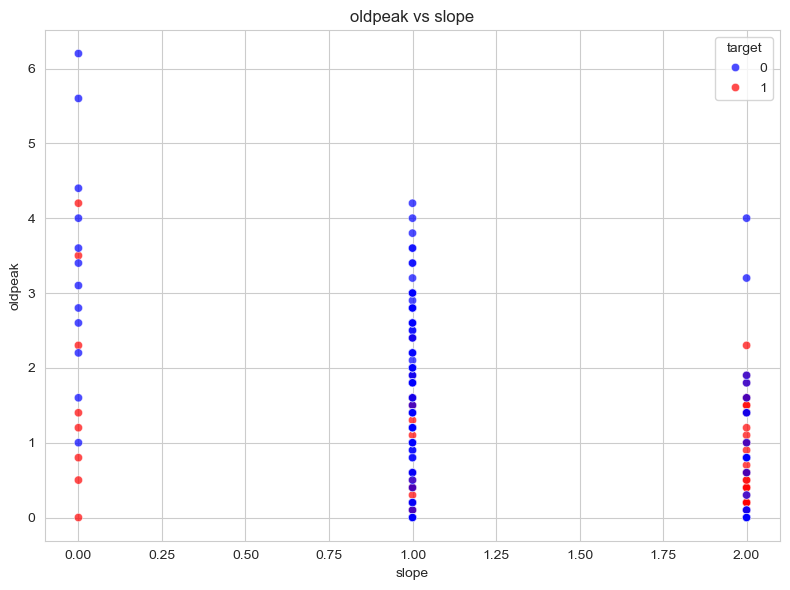

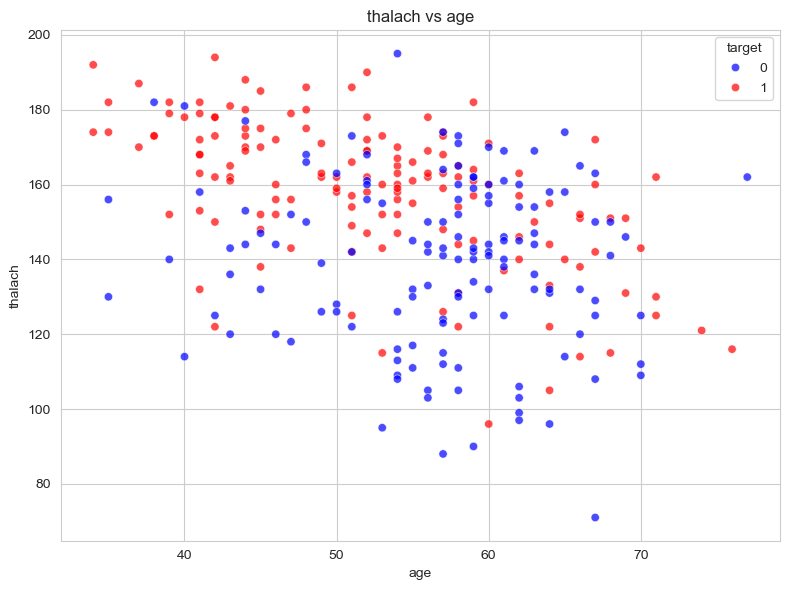

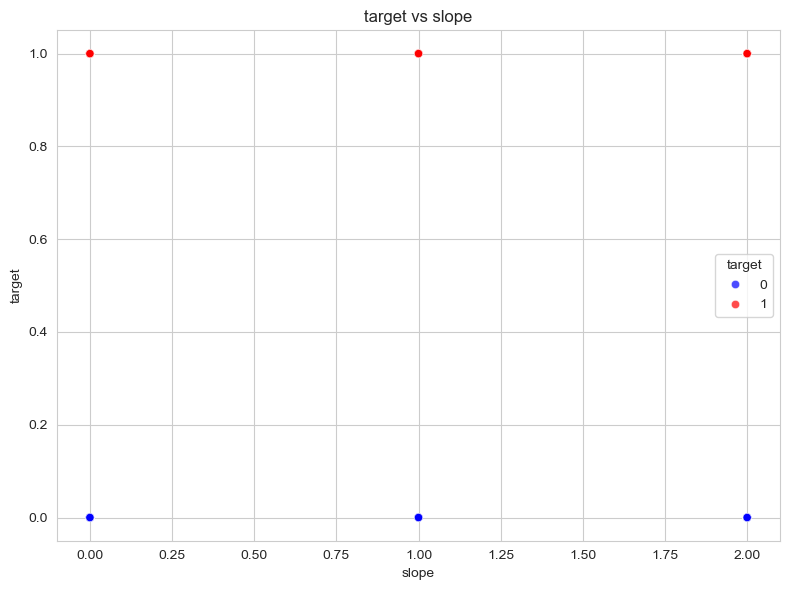

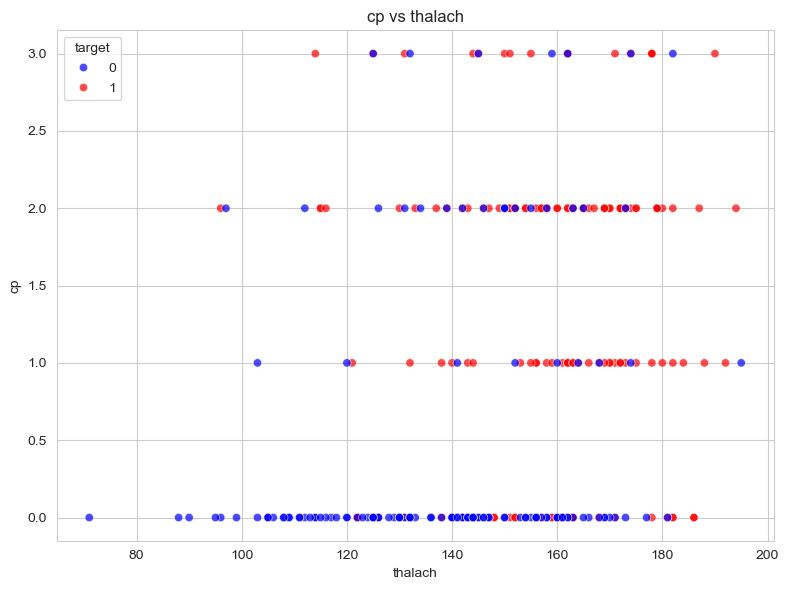

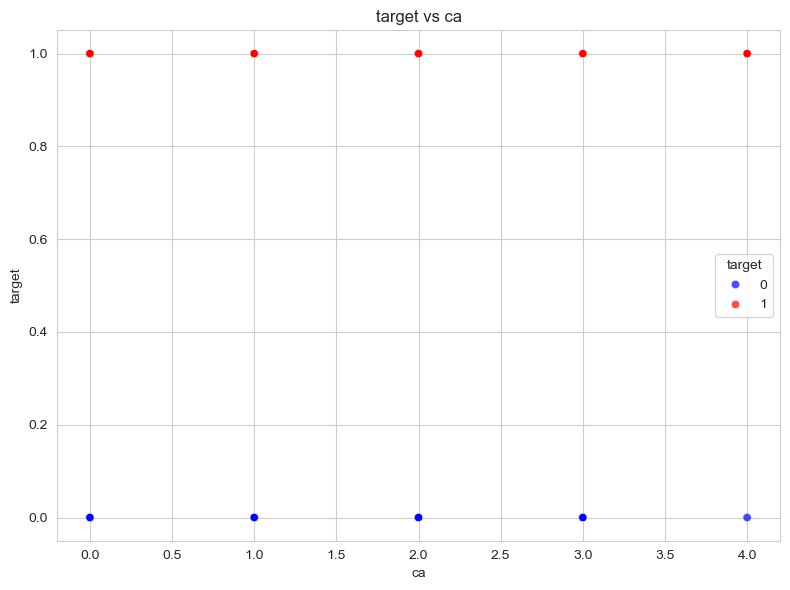

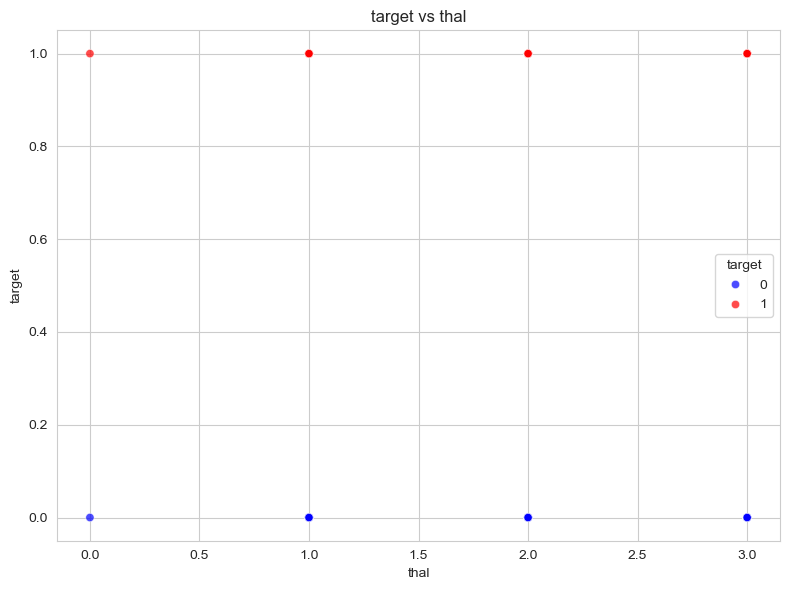

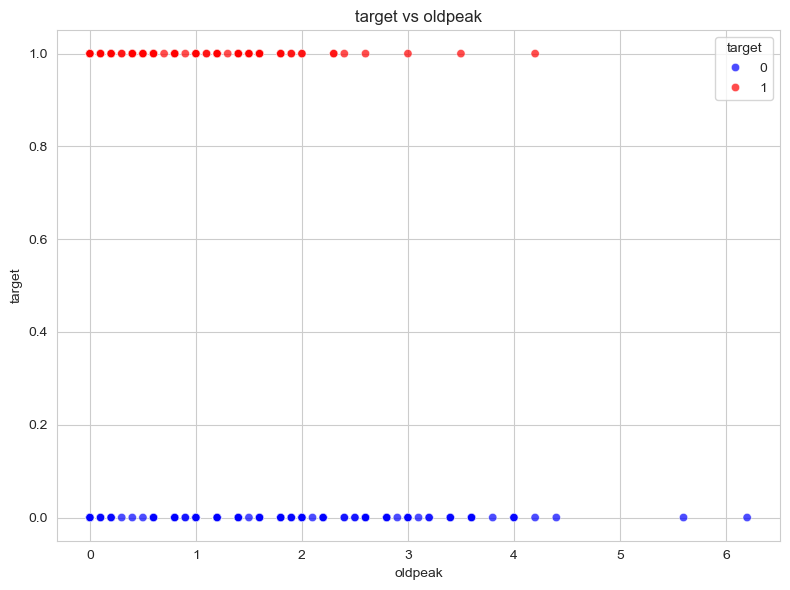

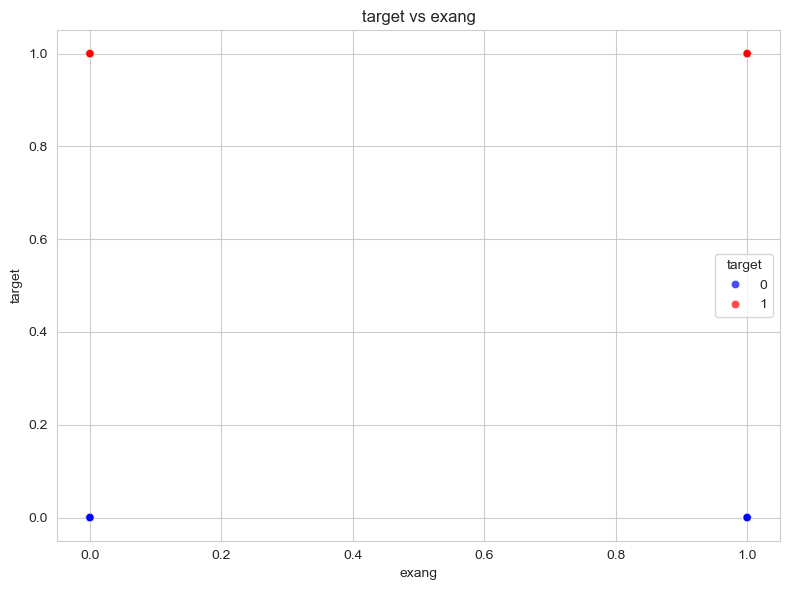

In [137]:
plt.rcParams['figure.figsize'] = (8, 6)
# Наиболее информативные пары
informative_pairs = [
    ('cp', 'target'),
    ('exang', 'thalach'),
    ('slope', 'oldpeak'),
    ('age', 'thalach'),
    ('slope', 'target'),
    ('thalach', 'cp'),
    ('ca', 'target'),
    ('thal', 'target'),
    ('oldpeak', 'target'),
    ('exang', 'target')
]

for x, y in informative_pairs:
    sns.scatterplot(data=df, x=x, y=y, hue='target', palette={0: 'blue', 1: 'red'}, alpha=0.7)
    plt.title(f'{y} vs {x}')
    plt.tight_layout()
    plt.show()

## Outliers analysis 

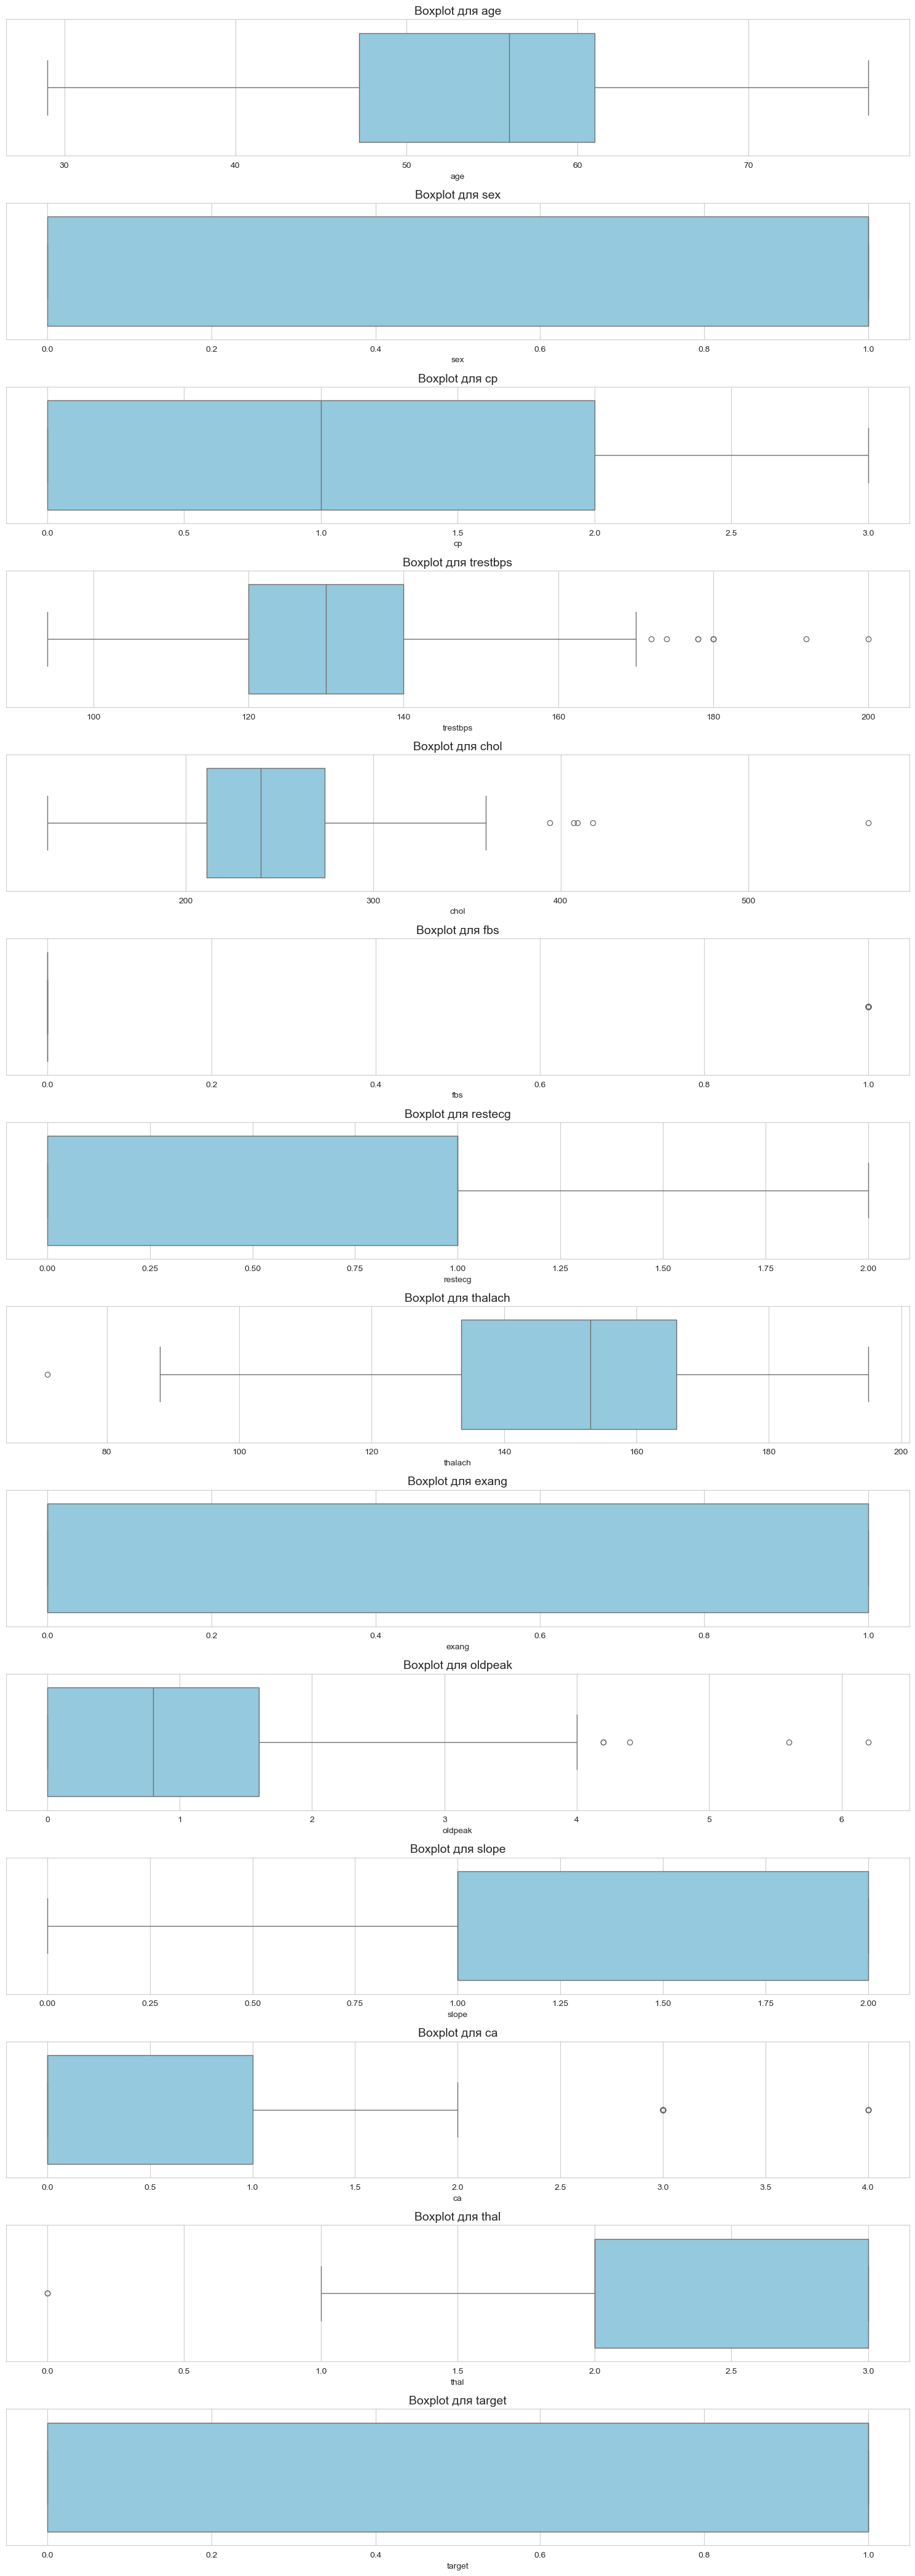

In [138]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_info = {}

num_features = len(numeric_cols)
plt.figure(figsize=(15, num_features * 3))

# Проходим по каждой числовой колонке
for i, col in enumerate(numeric_cols, 1):
    col_data = df[col].dropna()  # убираем NaN для анализа
    
    # Вычисление границ IQR
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Определяем аутлайеры
    outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
    outlier_info[col] = {
        "count": len(outliers),
        "percent": round(len(outliers) / len(col_data) * 100, 2),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_values": outliers.unique()
    }
    
    plt.subplot(num_features, 1, i)
    sns.boxplot(x=col_data, color="skyblue")
    plt.title(f"Boxplot для {col}", fontsize=14)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [139]:
outlier_info

{'age': {'count': 0,
  'percent': 0.0,
  'lower_bound': np.float64(26.625),
  'upper_bound': np.float64(81.625),
  'outlier_values': array([], dtype=float64)},
 'sex': {'count': 0,
  'percent': 0.0,
  'lower_bound': np.float64(-1.5),
  'upper_bound': np.float64(2.5),
  'outlier_values': array([], dtype=float64)},
 'cp': {'count': 0,
  'percent': 0.0,
  'lower_bound': np.float64(-3.0),
  'upper_bound': np.float64(5.0),
  'outlier_values': array([], dtype=float64)},
 'trestbps': {'count': 9,
  'percent': 3.01,
  'lower_bound': np.float64(90.0),
  'upper_bound': np.float64(170.0),
  'outlier_values': array([172., 178., 180., 200., 174., 192.])},
 'chol': {'count': 5,
  'percent': 1.68,
  'lower_bound': np.float64(116.5),
  'upper_bound': np.float64(368.5),
  'outlier_values': array([417., 564., 394., 407., 409.])},
 'fbs': {'count': 44,
  'percent': 14.72,
  'lower_bound': np.float64(0.0),
  'upper_bound': np.float64(0.0),
  'outlier_values': array([1.])},
 'restecg': {'count': 0,
  'perc

### Самые «шумные» признаки по выбросам: chol, trestbps, thalach, oldpeak.

## Split

In [140]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [141]:
train = X_train.copy()
train['target'] = y_train

test = X_test.copy()
test['target'] = y_test

## Missing value imputation

## Log-transformation and Robust Scaler for skewed variables

In [142]:
train_clean = train.copy()
test_clean = test.copy()

# Лог-преобразование для chol, trestbps, oldpeak (только положительные значения)
for col in ['chol', 'trestbps','thalach','oldpeak']:
    train_clean[col] = train_clean[col].apply(lambda x: np.log1p(x) if x > 0 else x)
    test_clean[col] = test_clean[col].apply(lambda x: np.log1p(x) if x > 0 else x)


# Масштабирование устойчивым к выбросам методом (RobustScaler)
scaler = RobustScaler()
scaled_cols = ['chol', 'trestbps', 'oldpeak', 'thalach']

# Подгоняем scaler
train_clean[scaled_cols] = scaler.fit_transform(train_clean[scaled_cols])
test_clean[scaled_cols] = scaler.transform(test_clean[scaled_cols])

In [143]:
train_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
137,62.0,1.0,1.0,-0.100575,-0.516918,1.0,0.0,-0.374853,0.0,-0.570878,2.0,0.0,2.0,1
106,69.0,1.0,3.0,1.348029,-0.125471,1.0,0.0,-0.677561,0.0,-0.478309,1.0,1.0,2.0,1
284,61.0,1.0,0.0,0.480897,-0.532931,0.0,0.0,-0.440417,1.0,0.463204,2.0,1.0,3.0,0
44,39.0,1.0,2.0,0.480897,0.926054,0.0,0.0,0.821724,0.0,-0.570878,2.0,0.0,2.0,1
139,64.0,1.0,0.0,-0.100575,0.263013,0.0,1.0,-1.684305,1.0,-0.393801,1.0,1.0,3.0,1


In [144]:
test_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
225,70.0,1.0,0.0,0.708700,-1.109669,0.0,1.0,-0.891060,1.0,0.673207,0.0,0.0,3.0,0
152,64.0,1.0,3.0,1.741958,-0.226428,0.0,0.0,0.089117,0.0,-0.114395,1.0,0.0,3.0,1
228,59.0,1.0,3.0,1.741958,0.565075,0.0,0.0,0.205311,0.0,-0.393801,1.0,0.0,3.0,0
201,60.0,1.0,0.0,-0.254400,0.199176,0.0,0.0,-0.342419,1.0,0.725719,1.0,1.0,3.0,0
52,62.0,1.0,2.0,0.000000,-0.168365,0.0,1.0,-0.183601,0.0,0.429122,1.0,3.0,3.0,1


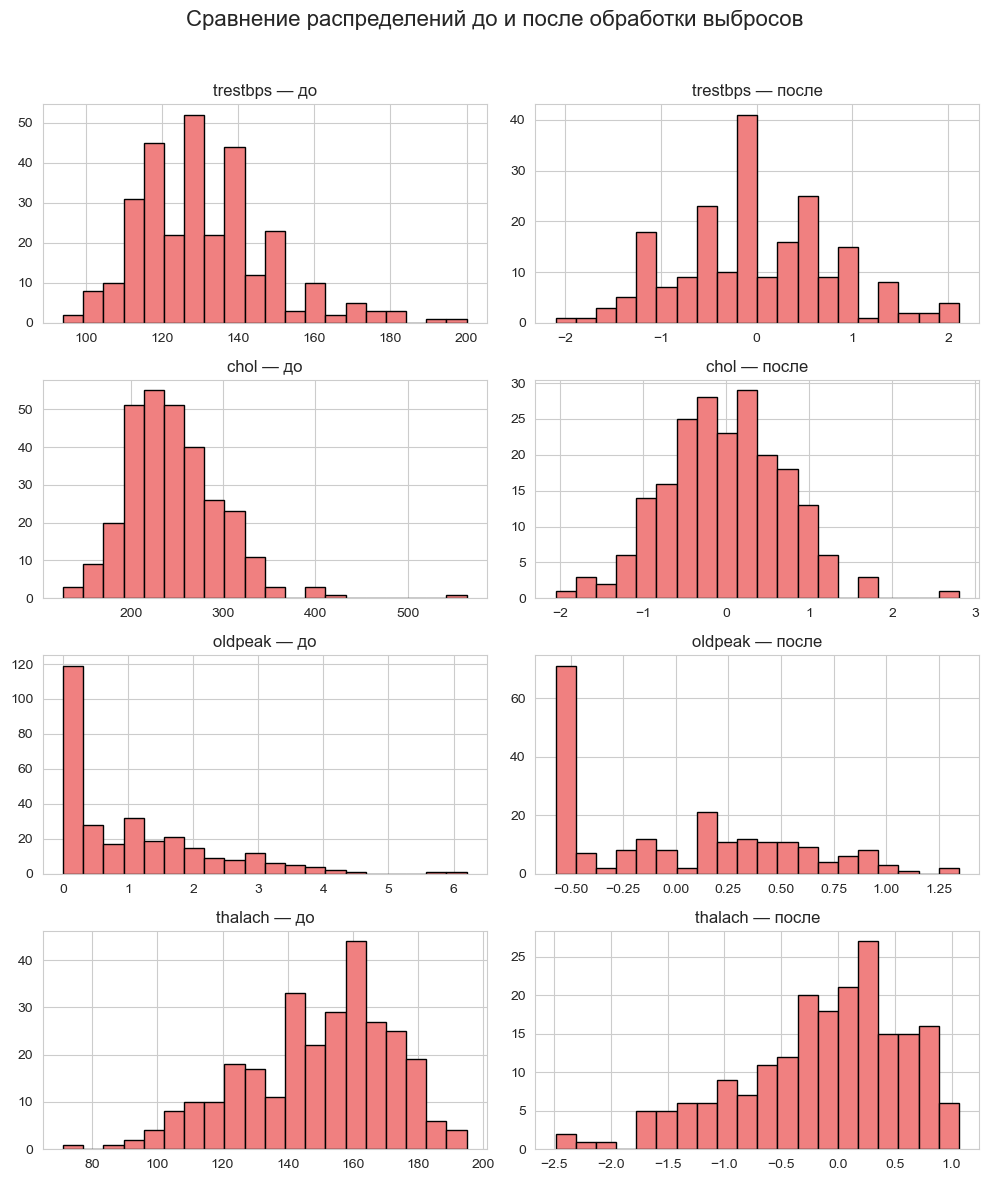

In [145]:
# Сравнение распределений до и после обработки

cols_to_compare = ['trestbps', 'chol', 'oldpeak', 'thalach']

fig, axes = plt.subplots(len(cols_to_compare), 2, figsize=(10, 12))
fig.suptitle("Сравнение распределений до и после обработки выбросов", fontsize=16)

for i, col in enumerate(cols_to_compare):
    # До 
    axes[i, 0].hist(df[col], bins=20, color='lightcoral', edgecolor='black')
    axes[i, 0].set_title(f"{col} — до")
    
    # После
    axes[i, 1].hist(train_clean[col], bins=20, color='lightcoral', edgecolor='black')
    axes[i, 1].set_title(f"{col} — после")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Base model

In [146]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target = 'target'
X_train, X_test, y_train, y_test = train_test_split(
    df[num_cols + cat_cols], df[target], test_size=0.3, stratify=df[target], # чтобы train и test имели одинаковое распределение целевой переменной.
    random_state=0
)

In [147]:
# Preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
]) 

# Models
models = {
    "LogReg": LogisticRegression(max_iter=500,
                                 class_weight='balanced', 
                                 penalty='l2', solver='lbfgs'),
    "RandomForest": RandomForestClassifier(n_estimators=500, 
                                           random_state=0, 
                                           class_weight='balanced', 
                                           max_depth=6, 
                                           min_samples_leaf=10,
                                           min_samples_split=20, 
                                           max_features='sqrt', n_jobs=-1
)}

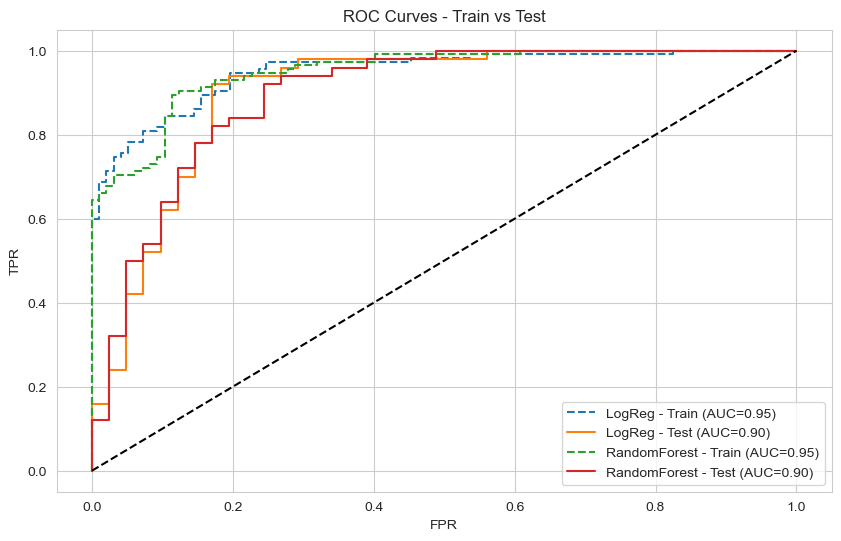

In [148]:
# Roc curves
plt.figure(figsize=(10,6))
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    
    for split, X, y, linestyle in [("Train", X_train, y_train, "--"), ("Test", X_test, y_test, "-")]:
        y_proba = pipe.predict_proba(X)[:,1]
        fpr, tpr, _ = roc_curve(y, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linestyle, label=f"{name} - {split} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curves - Train vs Test")
plt.legend()
plt.show()

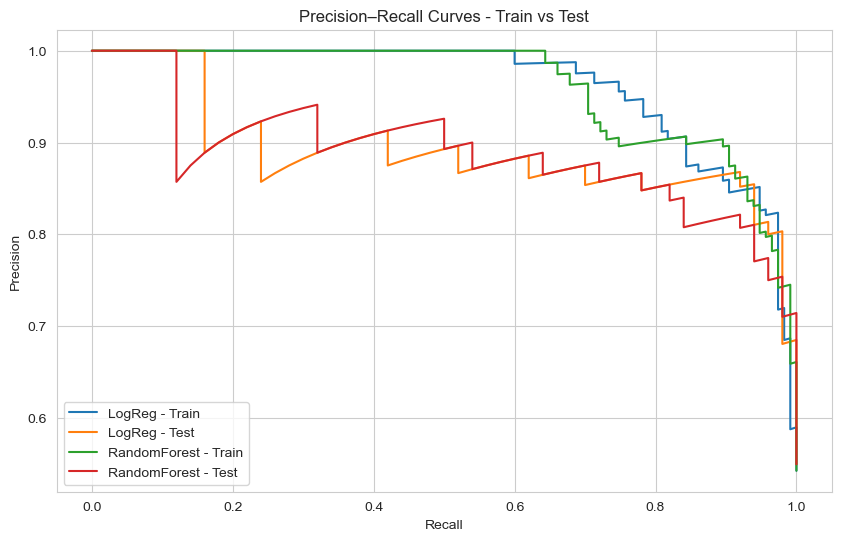

In [149]:
# Precision-Recall curves 
plt.figure(figsize=(10,6))
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)]).fit(X_train, y_train)
    
    for split, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        y_proba = pipe.predict_proba(X)[:,1]
        prec, rec, _ = precision_recall_curve(y, y_proba)
        plt.plot(rec, prec, label=f"{name} - {split}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curves - Train vs Test")
plt.legend()
plt.show()

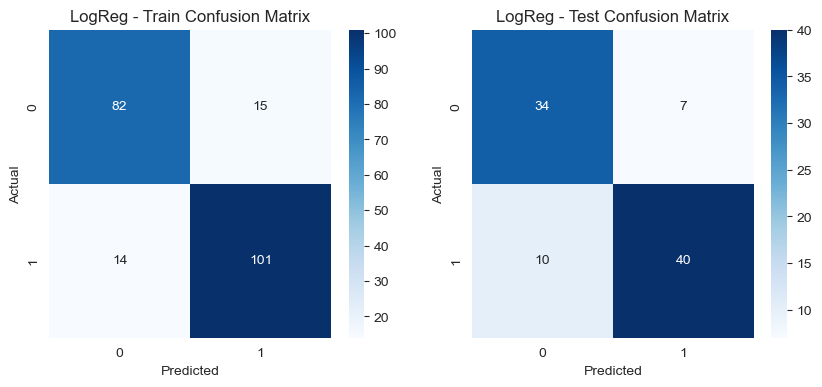


LogReg - Train Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        97
           1       0.87      0.88      0.87       115

    accuracy                           0.86       212
   macro avg       0.86      0.86      0.86       212
weighted avg       0.86      0.86      0.86       212


LogReg - Test Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        41
           1       0.85      0.80      0.82        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91



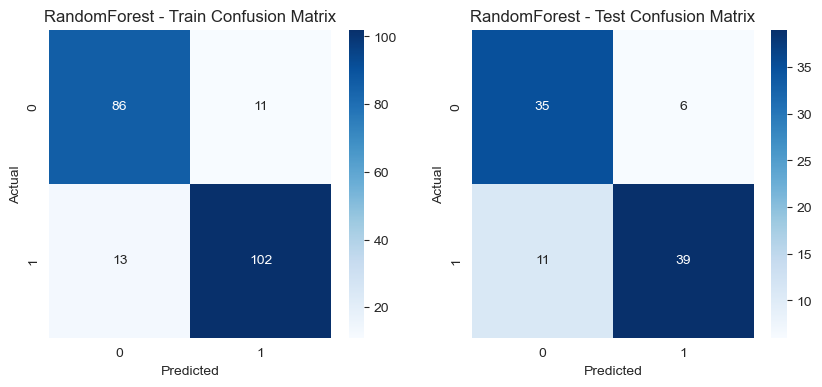


RandomForest - Train Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88        97
           1       0.90      0.89      0.89       115

    accuracy                           0.89       212
   macro avg       0.89      0.89      0.89       212
weighted avg       0.89      0.89      0.89       212


RandomForest - Test Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.85      0.80        41
           1       0.87      0.78      0.82        50

    accuracy                           0.81        91
   macro avg       0.81      0.82      0.81        91
weighted avg       0.82      0.81      0.81        91



In [150]:
# Confusion Matrices

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)]).fit(X_train, y_train)
    plt.figure(figsize=(10,4))
    
    for i, (split, X, y) in enumerate([("Train", X_train, y_train), ("Test", X_test, y_test)]):
        cm = confusion_matrix(y, pipe.predict(X))
        plt.subplot(1,2,i+1)
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.title(f"{name} - {split} Confusion Matrix")
    
    plt.show()
    
    # Classification report
    for split, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        y_pred = pipe.predict(X)
        print(f"\n{name} - {split} Classification Report:\n")
        print(classification_report(y, y_pred))

## Feature importance

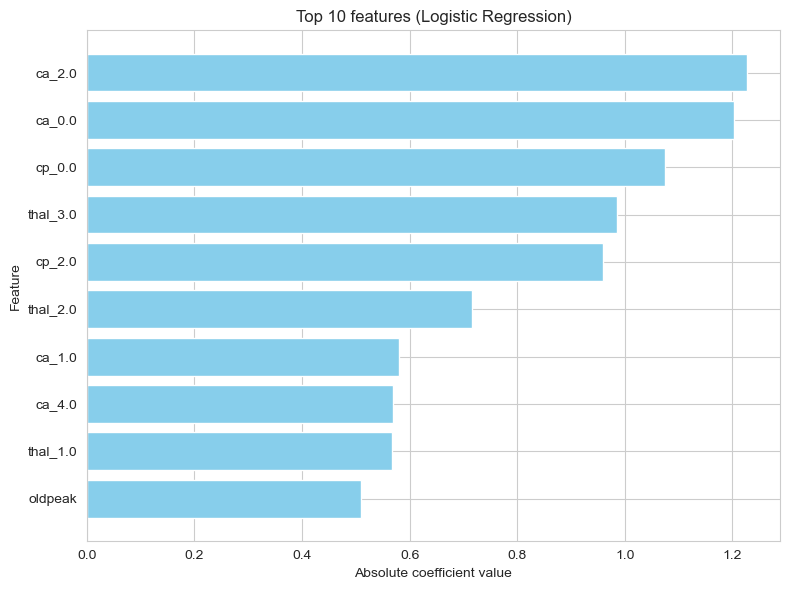

In [151]:
# Логистическая регрессия
logreg_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', random_state=42))
])
logreg_pipe.fit(X_train, y_train)

# Имена признаков
num_features = num_cols
cat_features = logreg_pipe.named_steps['prep'].named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_features, cat_features])

# Коэффициенты
coefs = logreg_pipe.named_steps['clf'].coef_[0]

logreg_importance = pd.DataFrame({
    'feature': all_features,
    'coef': coefs,
    'abs_coef': np.abs(coefs)}).sort_values('abs_coef', ascending=False)

top10 = logreg_importance.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top10['feature'], top10['abs_coef'], color='skyblue')
plt.gca().invert_yaxis()  # чтобы самый важный был сверху
plt.title("Top 10 features (Logistic Regression)")
plt.xlabel("Absolute coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

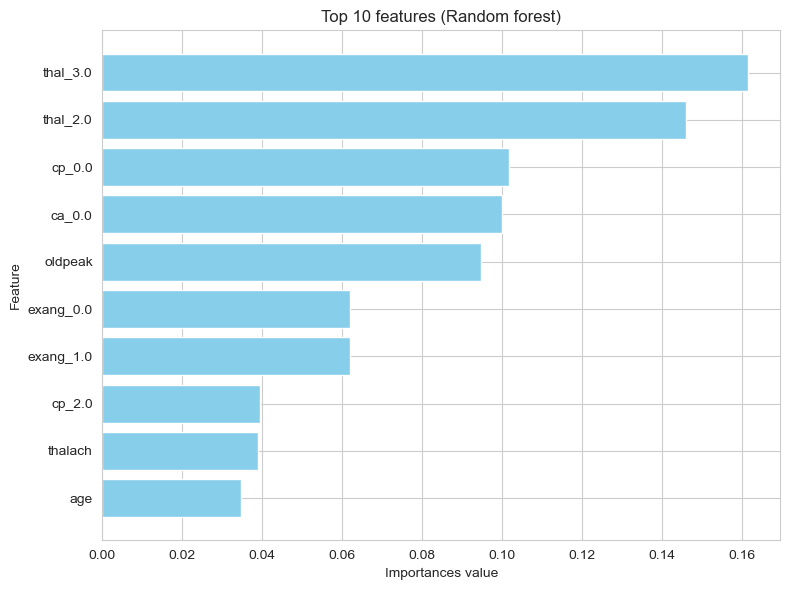

In [152]:
# Имена признаков после препроцессинга
num_features = num_cols
cat_features = pipe.named_steps['prep'].named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_features, cat_features])

importances = pipe.named_steps['clf'].feature_importances_

rf_importance = pd.DataFrame({
    'feature': all_features,
    'importance': importances}).sort_values('importance', ascending=False)

top10rf = rf_importance.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top10rf['feature'], top10rf['importance'], color='skyblue')
plt.gca().invert_yaxis()  # чтобы самый важный был сверху
plt.title("Top 10 features (Random forest)")
plt.xlabel("Importances value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature selection using Anova and mutual information

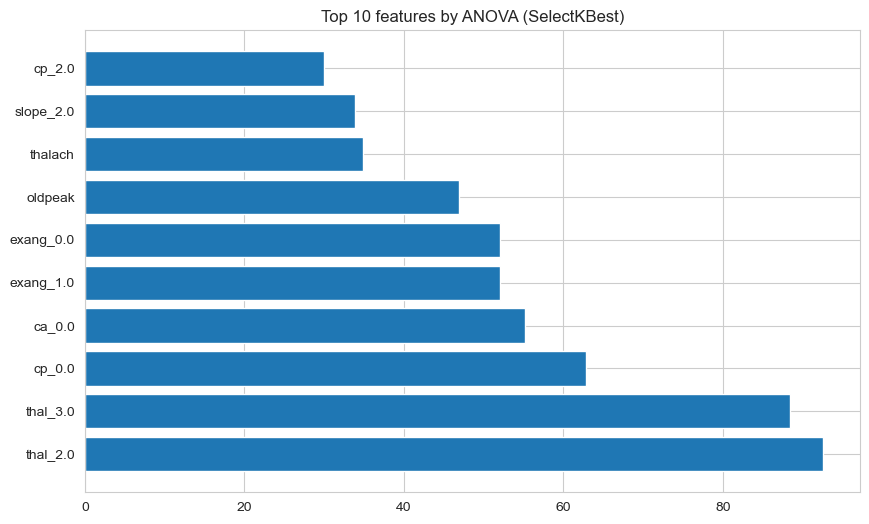

In [153]:
# прогоняем препроцессинг
preproc = preprocessor.fit(X_train, y_train)
Xtr = preproc.transform(X_train)

# имена признаков после OHE
cat_ohe = preproc.named_transformers_['cat']['ohe']
num_features = list(num_cols)
cat_features = list(cat_ohe.get_feature_names_out(cat_cols))
feature_names = np.array(num_features + cat_features)

# ANOVA KBest 
sel_anova = SelectKBest(score_func=f_classif, k=15)
sel_anova.fit(Xtr, y_train)
anova_scores = sel_anova.scores_

df_anova = pd.DataFrame({
    'feature': feature_names,
    'score': anova_scores
}).sort_values('score', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(df_anova['feature'], df_anova['score'])
plt.title("Top 10 features by ANOVA (SelectKBest)")
plt.show()

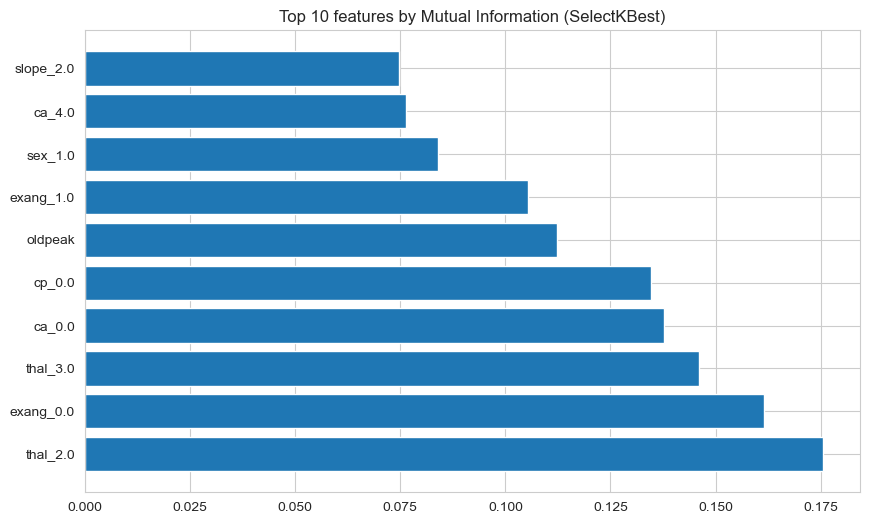

In [154]:
# MI KBest 
sel_mi = SelectKBest(score_func=mutual_info_classif, k=15)
sel_mi.fit(Xtr, y_train)
mi_scores = sel_mi.scores_

df_mi = pd.DataFrame({
    'feature': feature_names,
    'score': mi_scores
}).sort_values('score', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(df_mi['feature'], df_mi['score'])
plt.title("Top 10 features by Mutual Information (SelectKBest)")
plt.show()

## Selected features models


 LogReg + anova10 
Train Classification Report:
              precision    recall  f1-score   support

           0     0.8632    0.8454    0.8542        97
           1     0.8718    0.8870    0.8793       115

    accuracy                         0.8679       212
   macro avg     0.8675    0.8662    0.8667       212
weighted avg     0.8678    0.8679    0.8678       212

Test Classification Report:
              precision    recall  f1-score   support

           0     0.7907    0.8293    0.8095        41
           1     0.8542    0.8200    0.8367        50

    accuracy                         0.8242        91
   macro avg     0.8224    0.8246    0.8231        91
weighted avg     0.8256    0.8242    0.8245        91



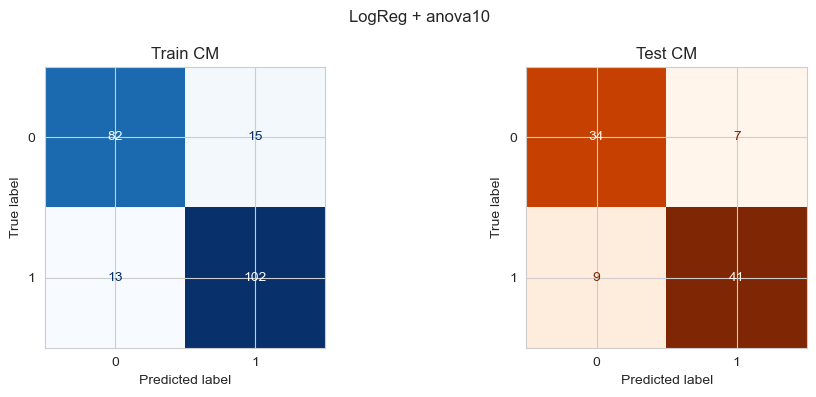


 LogReg + mi10 
Train Classification Report:
              precision    recall  f1-score   support

           0     0.8696    0.8247    0.8466        97
           1     0.8583    0.8957    0.8766       115

    accuracy                         0.8632       212
   macro avg     0.8639    0.8602    0.8616       212
weighted avg     0.8635    0.8632    0.8629       212

Test Classification Report:
              precision    recall  f1-score   support

           0     0.7907    0.8293    0.8095        41
           1     0.8542    0.8200    0.8367        50

    accuracy                         0.8242        91
   macro avg     0.8224    0.8246    0.8231        91
weighted avg     0.8256    0.8242    0.8245        91



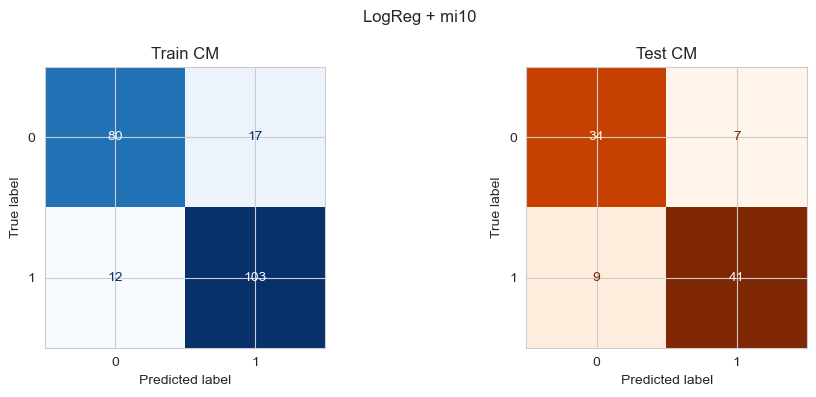


 RF + anova10 
Train Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        97
           1     1.0000    1.0000    1.0000       115

    accuracy                         1.0000       212
   macro avg     1.0000    1.0000    1.0000       212
weighted avg     1.0000    1.0000    1.0000       212

Test Classification Report:
              precision    recall  f1-score   support

           0     0.7273    0.7805    0.7529        41
           1     0.8085    0.7600    0.7835        50

    accuracy                         0.7692        91
   macro avg     0.7679    0.7702    0.7682        91
weighted avg     0.7719    0.7692    0.7697        91



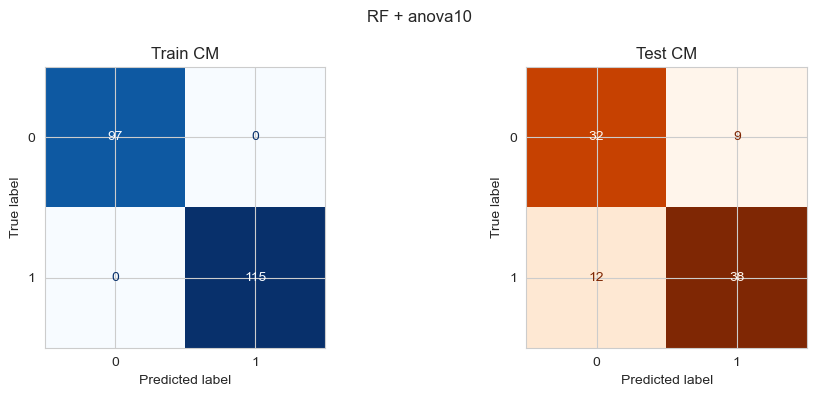


 RF + mi10 
Train Classification Report:
              precision    recall  f1-score   support

           0     0.9400    0.9691    0.9543        97
           1     0.9732    0.9478    0.9604       115

    accuracy                         0.9575       212
   macro avg     0.9566    0.9584    0.9573       212
weighted avg     0.9580    0.9575    0.9576       212

Test Classification Report:
              precision    recall  f1-score   support

           0     0.7083    0.8293    0.7640        41
           1     0.8372    0.7200    0.7742        50

    accuracy                         0.7692        91
   macro avg     0.7728    0.7746    0.7691        91
weighted avg     0.7791    0.7692    0.7696        91



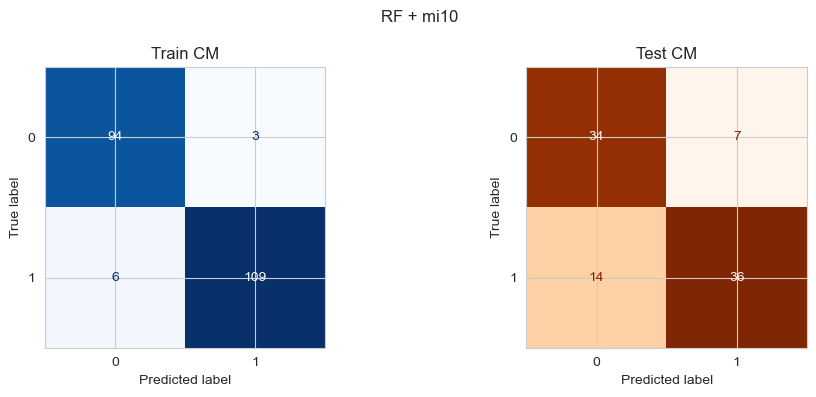


 DT + anova10 
Train Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        97
           1     1.0000    1.0000    1.0000       115

    accuracy                         1.0000       212
   macro avg     1.0000    1.0000    1.0000       212
weighted avg     1.0000    1.0000    1.0000       212

Test Classification Report:
              precision    recall  f1-score   support

           0     0.7000    0.6829    0.6914        41
           1     0.7451    0.7600    0.7525        50

    accuracy                         0.7253        91
   macro avg     0.7225    0.7215    0.7219        91
weighted avg     0.7248    0.7253    0.7249        91



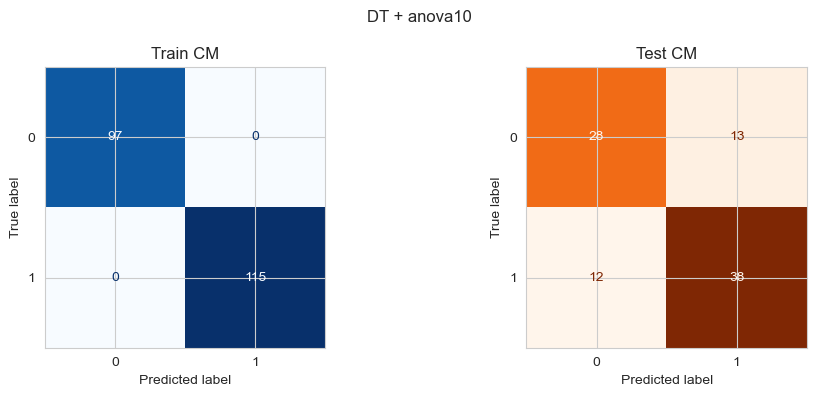


 DT + mi10 
Train Classification Report:
              precision    recall  f1-score   support

           0     0.9223    0.9794    0.9500        97
           1     0.9817    0.9304    0.9554       115

    accuracy                         0.9528       212
   macro avg     0.9520    0.9549    0.9527       212
weighted avg     0.9545    0.9528    0.9529       212

Test Classification Report:
              precision    recall  f1-score   support

           0     0.6875    0.8049    0.7416        41
           1     0.8140    0.7000    0.7527        50

    accuracy                         0.7473        91
   macro avg     0.7507    0.7524    0.7471        91
weighted avg     0.7570    0.7473    0.7477        91



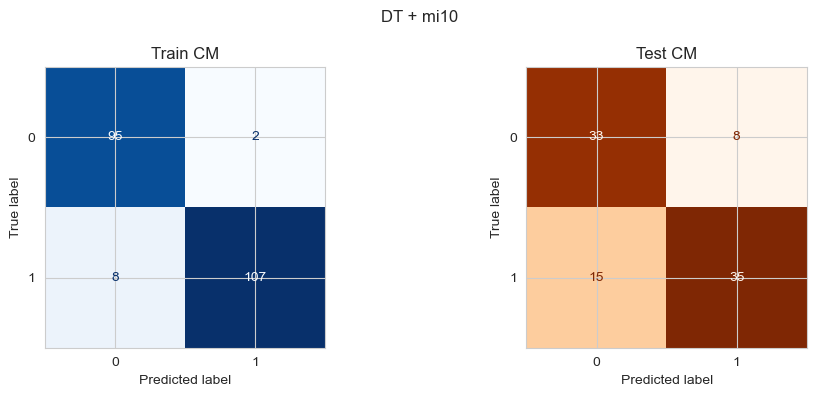

[LightGBM] [Info] Number of positive: 115, number of negative: 97
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 92
[LightGBM] [Info] Number of data points in the train set: 212, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

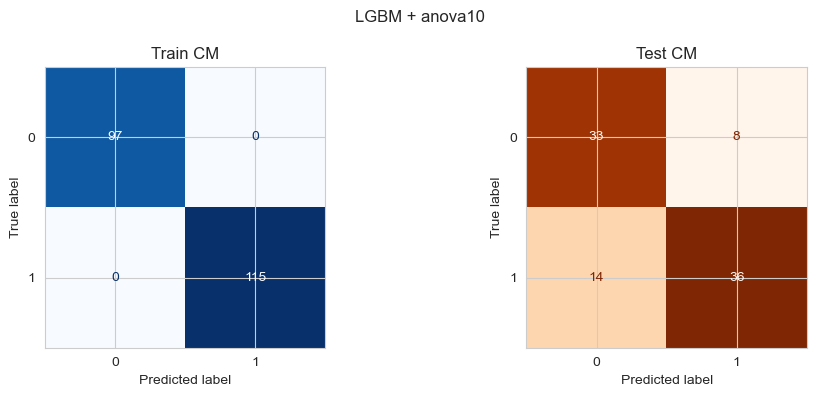

[LightGBM] [Info] Number of positive: 115, number of negative: 97
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42
[LightGBM] [Info] Number of data points in the train set: 212, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

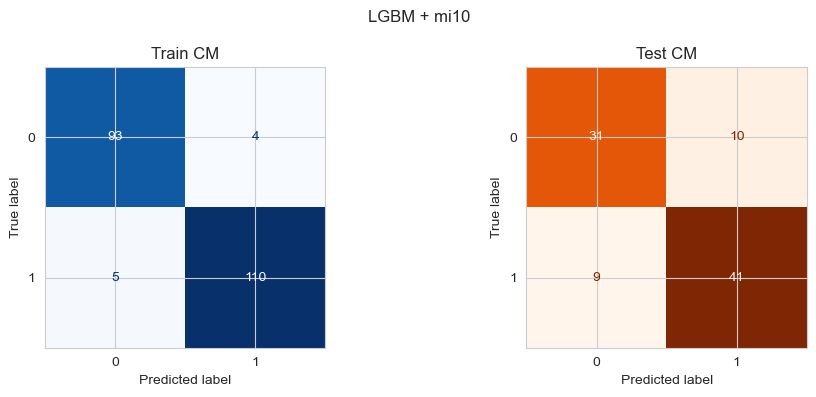


Summary table of metrics


In [155]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "RF": RandomForestClassifier(n_estimators=100, random_state=0, class_weight='balanced'),
    "DT": DecisionTreeClassifier(random_state=0, class_weight='balanced'),
    "LGBM": LGBMClassifier(
        n_estimators=200,
        random_state=0,
        class_weight='balanced',
        n_jobs=-1
    )
    
}

# Feature selection варианты
fs = {
    "anova10": SelectKBest(f_classif, k=10),
    "mi10": SelectKBest(mutual_info_classif, k=10)
}

results = []

for m_name, clf in models.items():
    for fs_name, fs_step in fs.items():
        pipe = Pipeline([
            ('prep', preprocessor),
            ('fs', fs_step),
            ('clf', clf)
        ])
        pipe.fit(X_train, y_train)
        y_pred_train = pipe.predict(X_train)
        y_proba_train = pipe.predict_proba(X_train)[:, 1]

        y_pred_test = pipe.predict(X_test)
        y_proba_test = pipe.predict_proba(X_test)[:, 1]

    
        metrics = {
            'train_roc_auc': roc_auc_score(y_train, y_proba_train),
            'test_roc_auc': roc_auc_score(y_test, y_proba_test),
            'train_precision': precision_score(y_train, y_pred_train),
            'test_precision': precision_score(y_test, y_pred_test),
            'train_recall': recall_score(y_train, y_pred_train),
            'test_recall': recall_score(y_test, y_pred_test),
        }

        results.append({
            'model': m_name,
            'fs': fs_name,
            **metrics
        })
 # Classification report 
        print(f"\n {m_name} + {fs_name} ")
        print("Train Classification Report:")
        print(classification_report(y_train, y_pred_train, digits=4))
        print("Test Classification Report:")
        print(classification_report(y_test, y_pred_test, digits=4))

        # Confusion matrices 
        cm_tr = confusion_matrix(y_train, y_pred_train)
        cm_te = confusion_matrix(y_test, y_pred_test)

        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ConfusionMatrixDisplay(cm_tr, display_labels=pipe.classes_).plot(
            ax=ax[0], cmap="Blues", values_format="d", colorbar=False
        )
        ax[0].set_title("Train CM")

        ConfusionMatrixDisplay(cm_te, display_labels=pipe.classes_).plot(
            ax=ax[1], cmap="Oranges", values_format="d", colorbar=False 
        )
        ax[1].set_title("Test CM")

        plt.suptitle(f"{m_name} + {fs_name}")
        plt.tight_layout()
        plt.show()

res_df = pd.DataFrame(results)
print("\nSummary table of metrics")

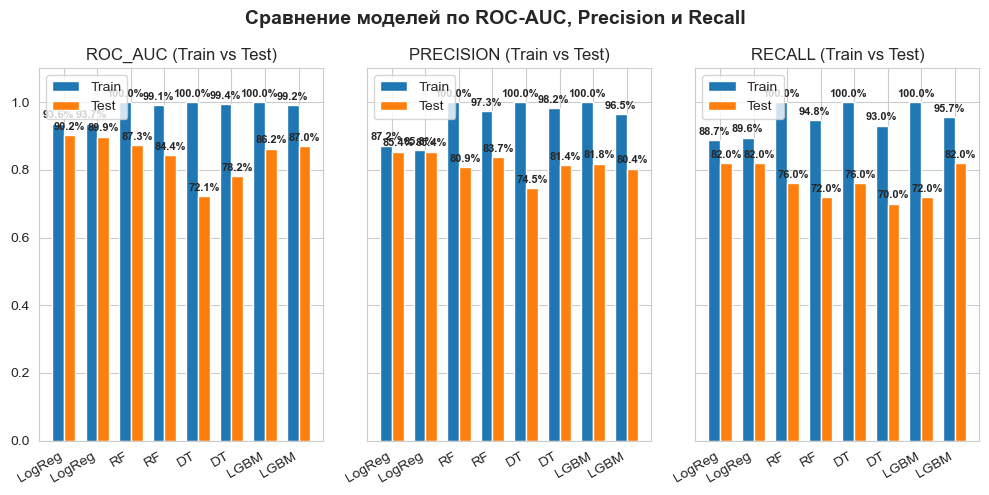

In [156]:
# Метрики для сравнения
metrics = ["roc_auc", "precision", "recall"]

fig, axes = plt.subplots(1, len(metrics), figsize=(10, 5), sharey=True)

for ax, metric in zip(axes, metrics):
    train_col = f"train_{metric}"
    test_col = f"test_{metric}"


    x = np.arange(len(res_df["model"]))
    width = 0.35

    # Построение баров
    bars_train = ax.bar(x - width/2, res_df[train_col], width, label="Train")
    bars_test = ax.bar(x + width/2, res_df[test_col], width, label="Test")

    # Подписи над барами
    for bars in [bars_train, bars_test]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height()*100:.1f}%",
                ha="center", va="bottom", fontsize=8, fontweight="bold"
            )

    # Оси и легенды
    ax.set_xticks(x)
    ax.set_xticklabels(res_df["model"], rotation=30, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{metric.upper()} (Train vs Test)", fontsize=12)
    ax.legend()

plt.suptitle("Сравнение моделей по ROC-AUC, Precision и Recall", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Выводы по моделям


Nодели  (ROC-AUC > 0.9).

Логистическая регрессия: стабильная, хорошо обобщает, AUC Train = 0.95, Test = 0.91.

Random Forest: склонен к переобучению (AUC Train = 0.95, Test = 0.89).

## Final model

In [157]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)

In [158]:
num_cols = list(X.select_dtypes(include=[np.number]).columns)
cat_cols_list = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']  # реальные категориальные

for col in cat_cols_list:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')
num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

## Preprocesing

In [159]:
# Для деревьев
preproc_tree = Pipeline(steps=[
    ('imp_num', MeanMedianImputer(imputation_method='median', variables=num_cols)),
    ('imp_cat', CategoricalImputer(imputation_method='frequent', variables=cat_cols_list))
])

# Для логистической регрессии
preproc_logreg = Pipeline(steps=[
    ('imp_num', MeanMedianImputer(imputation_method='median', variables=num_cols)),
    ('imp_cat', CategoricalImputer(imputation_method='frequent', variables=cat_cols_list)),
    ('winsor', Winsorizer(capping_method='quantiles', tail='both', fold=0.02, variables=['trestbps', 'chol'])),
    ('ohe', ce.OneHotEncoder(cols=cat_cols_list, use_cat_names=True, handle_unknown='ignore')),
    ('scale', SklearnTransformerWrapper(RobustScaler(), variables=num_cols))
])

## Pipeline

In [160]:
# Модели
models = {
    "LogReg": Pipeline([
        ('preprocess', preproc_logreg),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    "RandomForest": Pipeline([
        ('preprocess', preproc_tree),
        ('model', RandomForestClassifier(random_state=0, class_weight='balanced'))
    ]),
    "DecisionTree": Pipeline([
        ('preprocess', preproc_tree),
        ('model', DecisionTreeClassifier(random_state=0, class_weight='balanced'))
    ]),
    "LightGBM": Pipeline([
        ('preprocess', preproc_tree),
        ('model', LGBMClassifier(random_state=0, class_weight='balanced'))
    ])
}

In [161]:
# GridSearchCV 
param_grids = {
    "LogReg": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2", "l1"],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "RandomForest": {
        "model__n_estimators": [500, 100],
        "model__max_depth": [2, 4, 6, None],
        "model__min_samples_split": [2, 10, 20],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", "log2"]
    },
    "DecisionTree": {
        "model__max_depth": [1, 3, 5, 6, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 5, 10]
    },
    "LightGBM": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [2, 4, 6, -1],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0]
    }
}

In [162]:
# GridSearchCV и сбор метрик
results = []
best_models = {}  

for name, model in models.items():
    print(f"\nSearching {name}")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring="recall", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_  

    y_pred_train = best_models[name].predict(X_train)
    y_pred_test = best_models[name].predict(X_test)

    y_proba_train = best_models[name].predict_proba(X_train)[:,1]
    y_proba_test = best_models[name].predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "precision_train": precision_score(y_train, y_pred_train),
        "precision_test": precision_score(y_test, y_pred_test),
        "ROC_AUC_train": roc_auc_score(y_train, y_proba_train),
        "ROC_AUC_test": roc_auc_score(y_test, y_proba_test),
        "recall_train": recall_score(y_train, y_pred_train),
        "recall_test": recall_score(y_test, y_pred_test),
        "BestParams": grid.best_params_
    })

results_df = pd.DataFrame(results)
print("\nFinal results:")
print(results_df)


Searching LogReg...

Searching RandomForest...

Searching DecisionTree...

Searching LightGBM...
[LightGBM] [Info] Number of positive: 115, number of negative: 97
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 226
[LightGBM] [Info] Number of data points in the train set: 212, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [164]:
best_models["LogReg"]

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imp_num', ...), ('imp_cat', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputation_method,'median'
,variables,"['age', 'trestbps', ...]"
,imputation_method,'frequent'


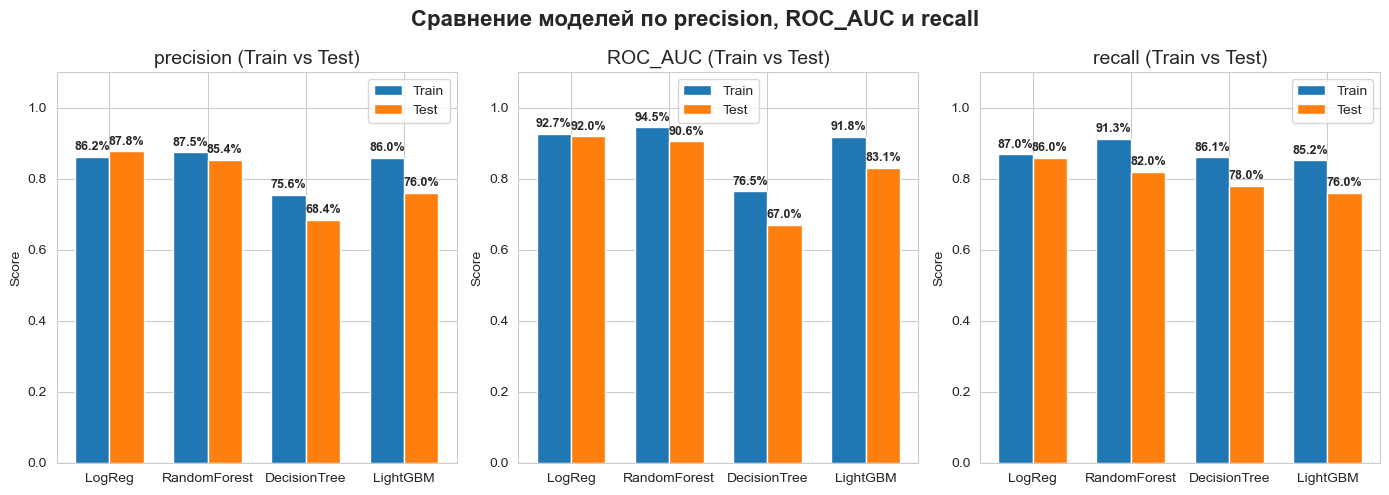

In [114]:
# Визуализация Train vs Test 
metrics = ["precision", "ROC_AUC", 'recall']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, metrics):
    train_col = f"{metric}_train"
    test_col = f"{metric}_test"

    x = np.arange(len(results_df["Model"]))
    width = 0.35

    bars_train = ax.bar(x - width/2, results_df[train_col], width, label="Train")
    bars_test = ax.bar(x + width/2, results_df[test_col], width, label="Test")

    # Подписи сверху
    for bars in [bars_train, bars_test]:
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height()*100:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(results_df["Model"])
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{metric} (Train vs Test)", fontsize=14)
    ax.set_ylabel("Score")
    ax.legend()

plt.suptitle("Сравнение моделей по precision, ROC_AUC и recall", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


LogReg — Classification Report (Train)
              precision    recall  f1-score   support

           0     0.8438    0.8351    0.8394        97
           1     0.8621    0.8696    0.8658       115

    accuracy                         0.8538       212
   macro avg     0.8529    0.8523    0.8526       212
weighted avg     0.8537    0.8538    0.8537       212

LogReg — Classification Report (Test)
              precision    recall  f1-score   support

           0     0.8333    0.8537    0.8434        41
           1     0.8776    0.8600    0.8687        50

    accuracy                         0.8571        91
   macro avg     0.8554    0.8568    0.8560        91
weighted avg     0.8576    0.8571    0.8573        91



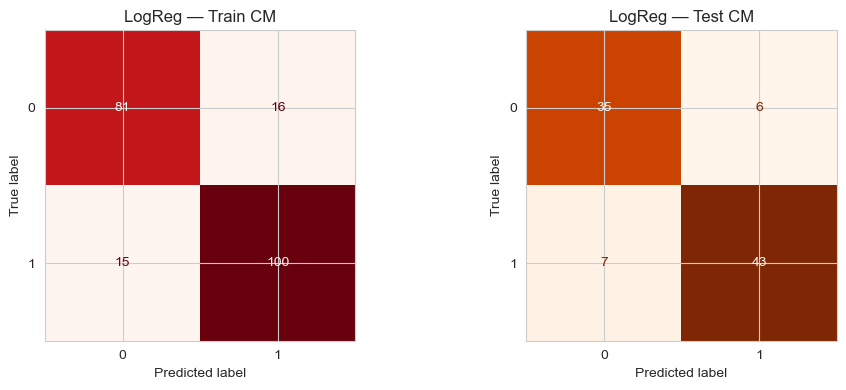


RandomForest — Classification Report (Train)
              precision    recall  f1-score   support

           0     0.8913    0.8454    0.8677        97
           1     0.8750    0.9130    0.8936       115

    accuracy                         0.8821       212
   macro avg     0.8832    0.8792    0.8807       212
weighted avg     0.8825    0.8821    0.8818       212

RandomForest — Classification Report (Test)
              precision    recall  f1-score   support

           0     0.7907    0.8293    0.8095        41
           1     0.8542    0.8200    0.8367        50

    accuracy                         0.8242        91
   macro avg     0.8224    0.8246    0.8231        91
weighted avg     0.8256    0.8242    0.8245        91



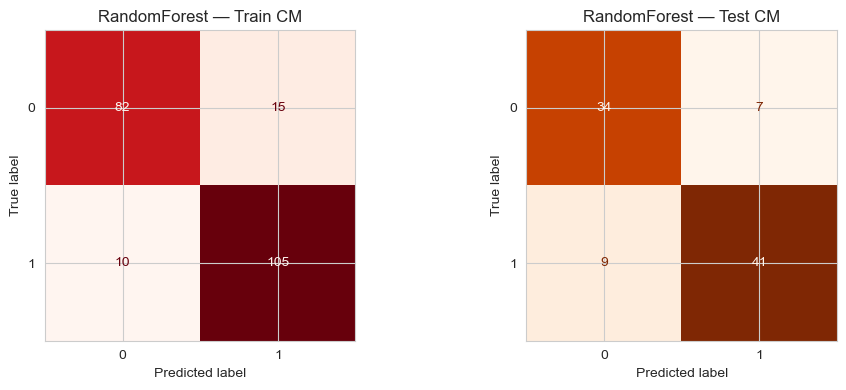


DecisionTree — Classification Report (Train)
              precision    recall  f1-score   support

           0     0.8025    0.6701    0.7303        97
           1     0.7557    0.8609    0.8049       115

    accuracy                         0.7736       212
   macro avg     0.7791    0.7655    0.7676       212
weighted avg     0.7771    0.7736    0.7708       212

DecisionTree — Classification Report (Test)
              precision    recall  f1-score   support

           0     0.6765    0.5610    0.6133        41
           1     0.6842    0.7800    0.7290        50

    accuracy                         0.6813        91
   macro avg     0.6803    0.6705    0.6712        91
weighted avg     0.6807    0.6813    0.6769        91



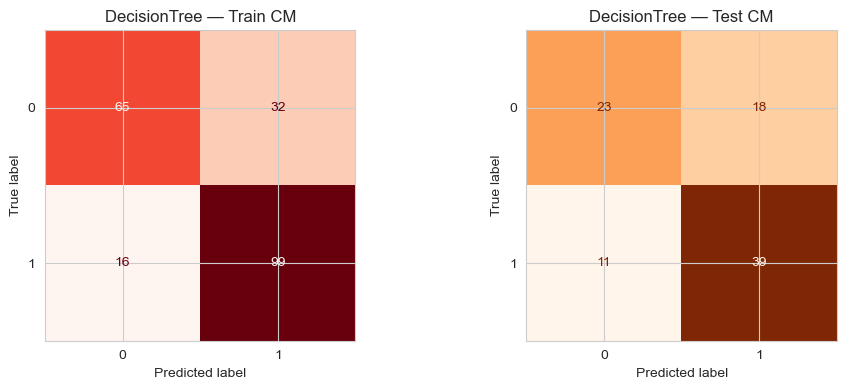


LightGBM — Classification Report (Train)
              precision    recall  f1-score   support

           0     0.8265    0.8351    0.8308        97
           1     0.8596    0.8522    0.8559       115

    accuracy                         0.8443       212
   macro avg     0.8431    0.8436    0.8433       212
weighted avg     0.8445    0.8443    0.8444       212

LightGBM — Classification Report (Test)
              precision    recall  f1-score   support

           0     0.7073    0.7073    0.7073        41
           1     0.7600    0.7600    0.7600        50

    accuracy                         0.7363        91
   macro avg     0.7337    0.7337    0.7337        91
weighted avg     0.7363    0.7363    0.7363        91



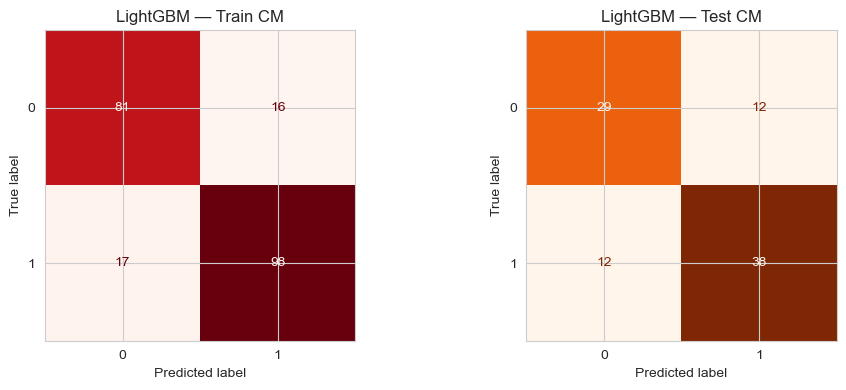

In [115]:
# Confusion Matrix и Classification Report

for name, est in best_models.items():
    y_pred_tr = est.predict(X_train)
    y_pred_te = est.predict(X_test)

    print(f"\n{name} — Classification Report (Train)")
    print(classification_report(y_train, y_pred_tr, digits=4))
    print(f"{name} — Classification Report (Test)")
    print(classification_report(y_test, y_pred_te, digits=4))

    cm_tr = confusion_matrix(y_train, y_pred_tr)
    cm_te = confusion_matrix(y_test, y_pred_te)

    # последний шаг пайплайна = сама модель
    final_model = list(est.named_steps.values())[-1]

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ConfusionMatrixDisplay(cm_tr, display_labels=final_model.classes_).plot(
        ax=ax[0], cmap="Reds", values_format="d", colorbar=False
    )
    ax[0].set_title(f"{name} — Train CM")

    ConfusionMatrixDisplay(cm_te, display_labels=final_model.classes_).plot(
        ax=ax[1], cmap="Oranges", values_format="d", colorbar=False
    )
    ax[1].set_title(f"{name} — Test CM")

    plt.tight_layout()
    plt.show()

## Best Model Logistic regression

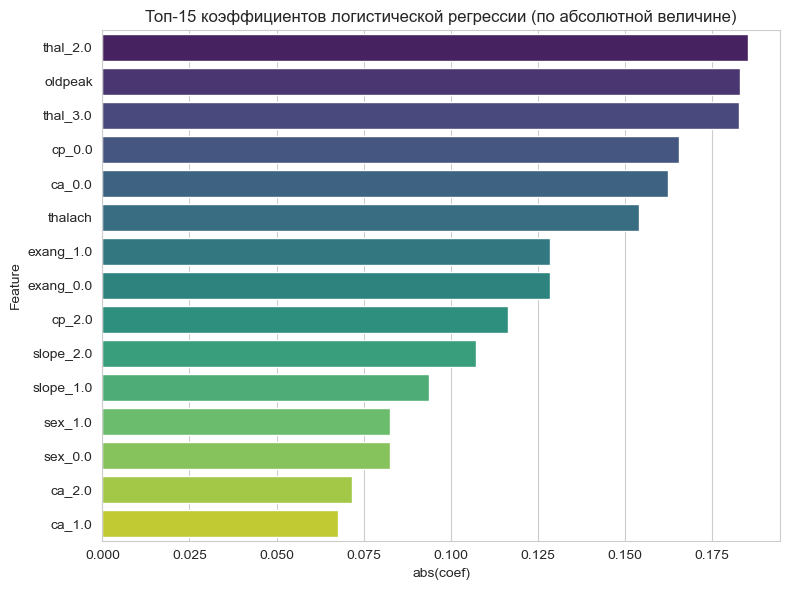

In [116]:
# Выбираем лучшую модель логрег из словаря best_models
if "LogReg" in best_models:
    logreg_est = best_models["LogReg"]
    final_model = list(logreg_est.named_steps.values())[-1]  

    
    coefs = final_model.coef_[0]
    feature_names = logreg_est[:-1].get_feature_names_out()  # все признаки после трансформаций

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    # Топ-15
    plt.figure(figsize=(8,6))
    sns.barplot(data=imp_df.head(15), x="abs_coef", y="feature", palette="viridis")
    plt.title("Топ-15 коэффициентов логистической регрессии (по абсолютной величине)")
    plt.xlabel("abs(coef)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## ВЫВОД

## Базовые модели
####  Дали средние результаты 
####  Показывали переобучение на обучающей выборке

## Лучшая модель — Logistic Regression:

#### Достигает высокой точности 
#### Хорошо интерпретируется, что особенно важно в медицине.
#### Предпочтительна для объяснимых решений и применения врачами.
#### Ансамбли (RF, LGBM) показывают близкие результаты, но для реальной медицины их сложнее объяснять.

#### Помощь использования моделей — не столько в точности, сколько в том, что они выявляют наиболее значимые клинические признаки риска болезни сердца.